# NVDIFFRAST

Theory is based on this [lecture](https://vkvideo.ru/video-227352629_456239080).

## Forward Rendering


Forward rendering:
$I = R({\theta})$, where

$I$ - is the pixel color

${\theta}$ - s the geometry, materials, etc.

The scene is represented by a set of parameters: geometry, materials, etc. This representation can be **explicit** (e.g., triangular mesh) or **implicit** (e.g., SDF, volumetric representation like NeRF). Different rendering methods are suited to different representations.

For this seminar, we use an **explicit** scene representation: Triangular mesh.


In classical graphics, there are two primary approaches to rendering images:

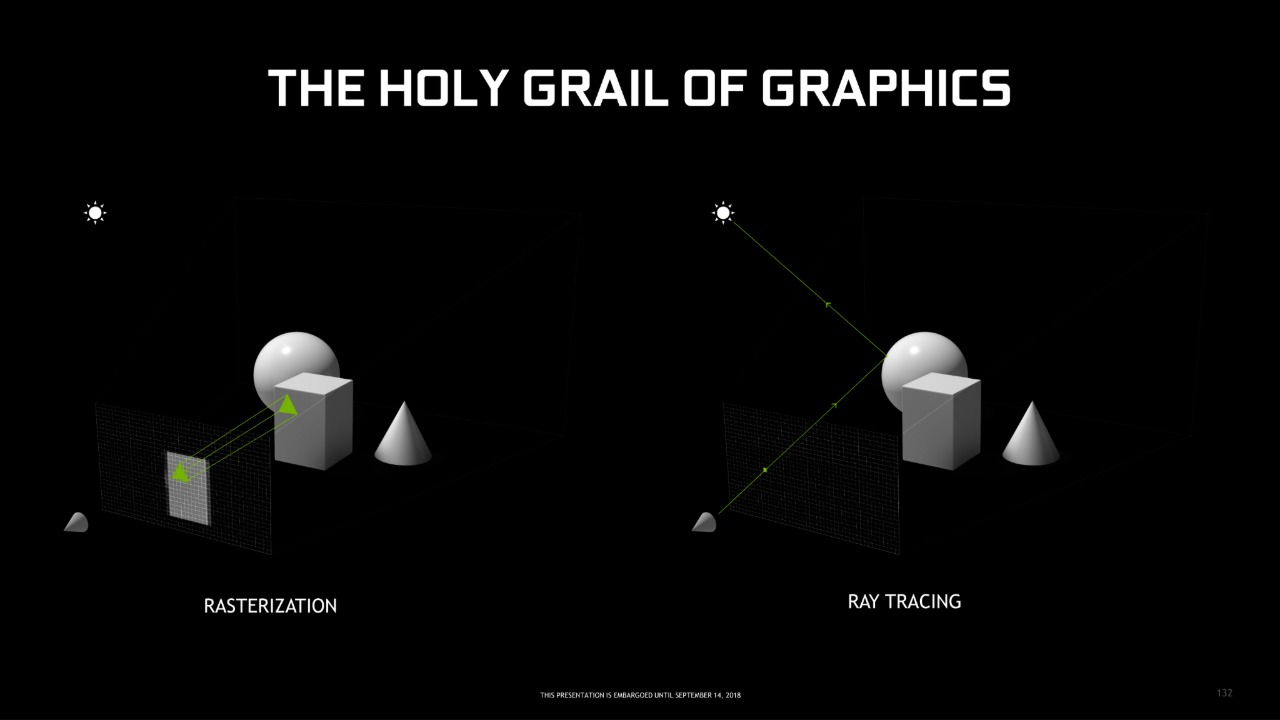

**Ray Tracing:**

We trace a ray (cast from the camera into the scene and track its path backwards towards light sources), checking for intersections with scene elements.

Upon intersection, we sample where the ray might reflect and continue tracing it.

Slow but accurate.


**Rasterization:**

We process individual scene primitives (e.g., triangles).

We assume a camera model where projecting a triangle onto the camera's projection plane results in another triangle (a 3D triangle projects to a 2D triangle).

We also assume opaque geometry (no semi-transparent objects).

The subject of this seminar is Rasterization.

## Inverse rendering

Inverse rendering: ${\theta} = R^{-1}(I)$ - is the process of reconstructing a scene from input images of that scene.

We frame it as an *optimization problem for the scene parameters ${\theta}$* with respect to a loss function $\mathcal{L}$ evaluated on a training dataset $D$:

$\underset{\theta}{\min} \mathcal{L}(\hat{I}, I \mid D)$ - to solve this, we need to compute derivatives with respect to the parameter ${\theta}$. This requires the ability to *differentiate the forward rendering pipelines.*

## Get started

In [13]:
!wget -q https://raw.githubusercontent.com/struminsky/hse_3dcv/2024/week_5/seminar/spot_triangulated.obj -O cow.obj

We downloaded .obj file. It consists of several types of lines:
* ```v 0.348799 -0.334989 -0.0832331``` - vertex
* ```vt 0.800375 0.667457``` - texture coordinate
* ```f 739/1 735/2 736/3``` - face (in general, ```f 1/2/3 4/5/6 7/8/9``` describes a triangular face, where each number represents the index of the vertex, texture coordinate, and normal, respectively)
* ...


In [2]:
!pip install --upgrade pip
!pip install trimesh xatlas

!pip install ninja pybind11 cmake setuptools wheel
!pip install git+https://github.com/NVlabs/nvdiffrast.git --no-build-isolation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.3/740.3 kB 15.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [trimesh]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ninja]
  Cloning https://github.com/NVlabs/nvdiffrast.git to /tmp/pip-req-build-ts2ylrh2
  Running command git clone --filter=blob:none --quiet https://github.com/NVlabs/nvdiffrast.git /tmp/pip-req-build-ts2ylrh2
  Resolved https://github.com/NVlabs/nvdiffrast.git to commit 253ac4fcea7de5f396371124af597e6cc957bfae
  Preparing metadata (pyproject.toml) ... done
  Created wheel for nvdiffrast: filename=nvdiffrast-0.4.0-cp312-cp312-linux_x86_64.whl size=16900209 sha256=6130ec181059b938b914357f45fe7493e1de8983b99e68b070a9ec6fede634f8
  Stored in directory: /tmp/pip-ephem-wheel-cache-9yqzyfa2/

In [3]:
import torch
import math
import numpy as np
from tqdm import trange, tqdm
import matplotlib.pylab as plt
from matplotlib.colors import hsv_to_rgb
from dataclasses import dataclass
from torch.nn.functional import normalize

import trimesh
import xatlas
import nvdiffrast.torch as dr

## Mesh and Camera

Let's load a mesh and initialize a camera.

In [4]:
def dehomogenize_points(points):
    return points[..., :-1] / points[..., -1:]

def homogenize_points(points):
    last_coordinate = torch.ones_like(points[..., -1:])
    return torch.cat((points, last_coordinate), dim=-1)

In [5]:
@dataclass
class Mesh:
    verts: torch.Tensor
    faces: torch.Tensor
    uvs: torch.Tensor
    normals: torch.Tensor

In [6]:
# We need them for vizuliazation
def get_normals(verts, faces):
    '''
    Calculate normals for all faces using cross product.
    '''
    p_0 = verts[faces[:, 0]]
    p_1 = verts[faces[:, 1]]
    p_2 = verts[faces[:, 2]]
    normals = np.cross(p_1 - p_0, p_2 - p_0, axis=-1)
    normals = normals / (np.linalg.norm(normals, axis=-1, keepdims=True) + 1e-8)

    assert verts.ndim == 2 and verts.shape[1] == 3, "Vertices should be Nx3"
    assert faces.ndim == 2 and faces.shape[1] == 3, "Faces should be Mx3"
    assert normals.shape == faces.shape, "Normals shape mismatch"

    return normals

In [7]:
def load_mesh(filename, device="cuda:0"):
    # read the mesh file
    my_mesh = trimesh.load_mesh(filename)

    # parametrize the uv map - this is for cases if we don't have it
    vmapping, indices, uvs = xatlas.parametrize(my_mesh.vertices,
                                                my_mesh.faces)

    # calculate the normals for the faces
    normals = get_normals(my_mesh.vertices, my_mesh.faces)

    my_mesh = Mesh(
        verts = torch.tensor(my_mesh.vertices[vmapping], dtype=torch.float32, device=device),
        faces = torch.tensor(indices.astype(np.int32), dtype=torch.int32, device=device),
        uvs   = torch.tensor(uvs, dtype=torch.float32, device=device),
        normals = torch.tensor(normals, dtype=torch.float32, device=device)
    )

    assert vmapping.ndim == 1, "Vertex mapping should be 1D array"
    assert indices.ndim == 2 and indices.shape[1] == 3, "Faces should be Nx3 array"
    assert uvs.ndim == 2 and uvs.shape[1] == 2, "UVs should be Nx2 array"
    assert normals.ndim == 2 and normals.shape[1] == 3, "Normals should be Nx3 array"

    return my_mesh

In [8]:
class Camera:
    def __init__(
        self,
        batch_size,
        device,
        phi=None,
        theta=None,
        camera_target=None,
        r=1.0
    ):
        # (phi, theta, r) - camera position in spherical coordinates
        if phi is None:
            phi = 0.5 * torch.pi + 0.8 * torch.randn(batch_size)

        if theta is None:
            theta = 0.125 * torch.pi + 0.2 * torch.randn(batch_size)

        if camera_target is None:
            camera_target = torch.tensor([0.0, 0.4, 0.0]).to(device)

        # Camera location in world coordinates in Euclidian coordinates
        self.camera_location = 2 * r * torch.stack([
            -torch.cos(phi) * torch.cos(theta),
            torch.sin(theta),
            -torch.sin(phi) * torch.cos(theta)
        ], dim=-1).to(device)

        # Let's make classical LookAt camera: https://www.scratchapixel.com/lessons/mathematics-physics-for-computer-graphics/lookat-function/framing-lookat-function.html
        y = torch.broadcast_to(torch.tensor([0., 1., 0.]), self.camera_location.shape).to(device)
        z = -normalize(camera_target - self.camera_location, dim=-1)
        x = normalize(torch.cross(z, y), dim=-1)
        y = normalize(torch.cross(x, z), dim=-1)

        self.x = x
        self.y = y
        self.z = z

        assert camera_target.shape == (3,), "Camera target must be 3D vector"
        assert phi.shape == theta.shape == (batch_size,), "Angle shapes mismatch"
        assert self.camera_location.shape == (batch_size, 3), "Camera location shape error"

    def get_mvp(self):
        '''
        The function builds an MVP (Model-View-Projection) matrix that converts coordinates from
        the world system to the screen projection.
        '''
        q_t = torch.stack([self.x, self.y, self.z], axis=-2)
        t = -(q_t * self.camera_location[:, None]).sum(-1)

        q_inv = torch.cat([q_t, t[..., None]], axis=-1)
        fourth_row = torch.tensor([0, 0, 0, 1.], device=self.x.device).view(1, 1, -1)
        fourth_row = fourth_row.repeat(q_inv.shape[0], 1, 1)
        q_inv = torch.cat([q_inv, fourth_row], axis=1).to(self.x.device)

        n = 0.2 # near
        f = 10  # far
        proj = torch.tensor([[f * n,        0,            0,                 0         ],
                             [  0,      - f * n,          0,                 0         ],
                             [  0,          0,      -(f+n)/(f-n),    -(2*f*n)/(f-n)    ],
                             [  0,          0,           -1,                 0         ]], device=self.x.device)

        return torch.einsum('ij, bjk->bik', proj, q_inv)

In [14]:
my_mesh = load_mesh('cow.obj', "cuda:0")
my_camera = Camera(1, "cuda:0")

/tmp/ipython-input-2313/3423652362.py:31: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  x = normalize(torch.cross(z, y), dim=-1)


In [15]:
assert my_mesh.verts.shape[0] == my_mesh.uvs.shape[0], "Vertex-UV count mismatch"
assert torch.all(my_mesh.faces >= 0), "Negative face indices"
assert torch.all(my_mesh.faces < len(my_mesh.verts)), "Face indices out of bounds"

## Part with nvdiffrast

Mesh is a representation of an Object in a Scene (vertices and vertex indices connected into triangles)


$\color{green}{Green}$ $\color{green}{blocks}$ - defined by the user

$\color{gold}{Yellow}$ $\color{gold}{blocks}$ - defined by nvdiffrast

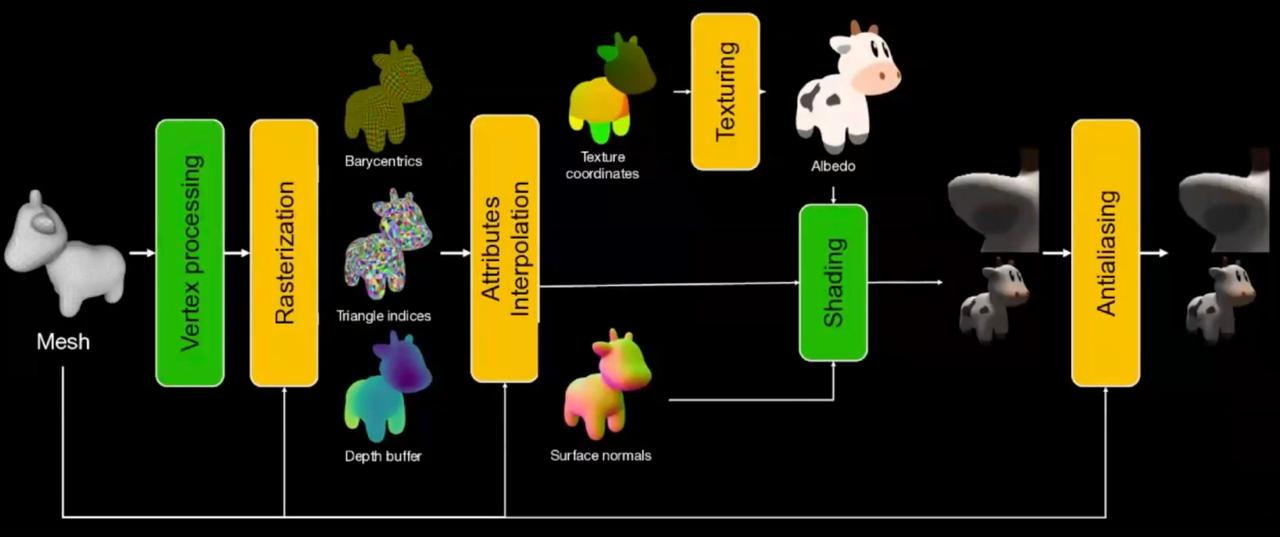

Picture from this [lecture](https://vkvideo.ru/video-227352629_456239090).

# First Stage of Rendering
We need to transform the vertices of the Mesh onto the plane of the camera's projection screen.



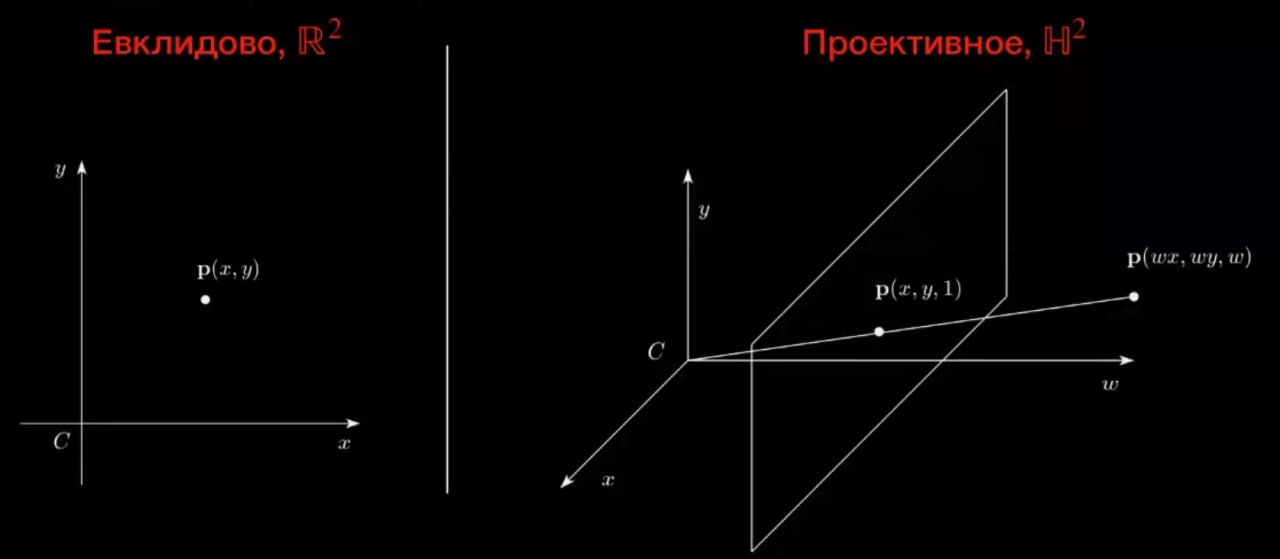

To understand how vertices are transformed, we need to use **projective space**.

In Euclidean space, a point on the camera screen plane is simply two coordinates, a point $(x, y)$.
However, it is more convenient to use projective space, where a point has 3 coordinates. That is, a single point in Euclidean space corresponds to an infinite number of points in projective space lying along a ray emanating from the camera's optical center.

$$ p(x, y) \in \mathbb{R}^2 ↔  p(wx, wy, w) \in \mathbb{H}^2$$

$p(x, y)$ - Euclidean coordinates

$p(wx, wy, w)$ - homogeneous coordinates

### Vertex processing

<table>
  <tr>
    <td>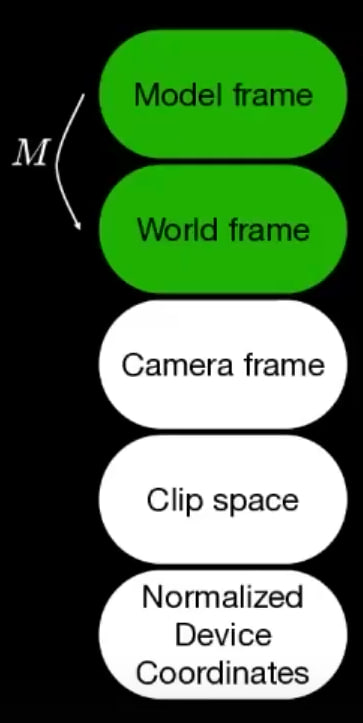</td>
    <td>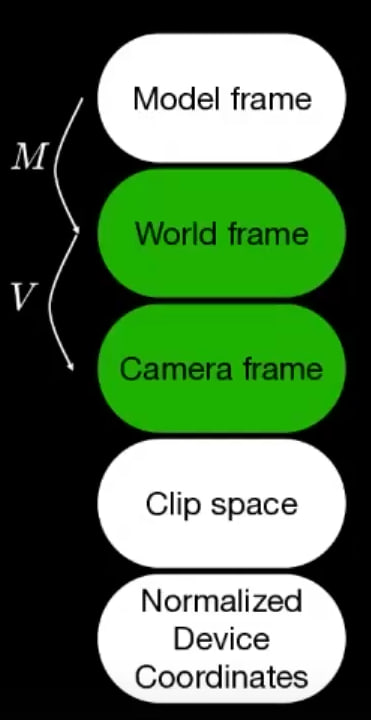</td>
    <td>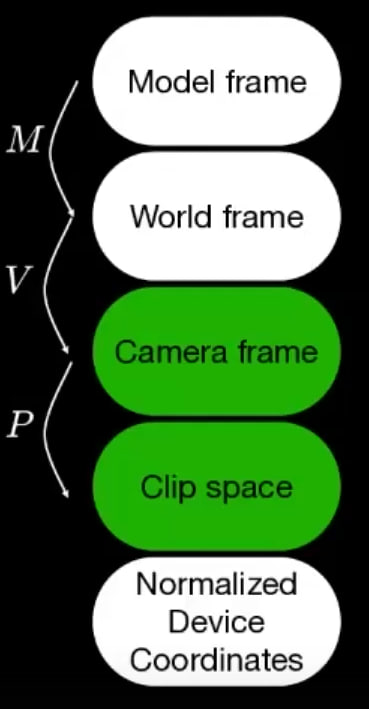</td>
    <td>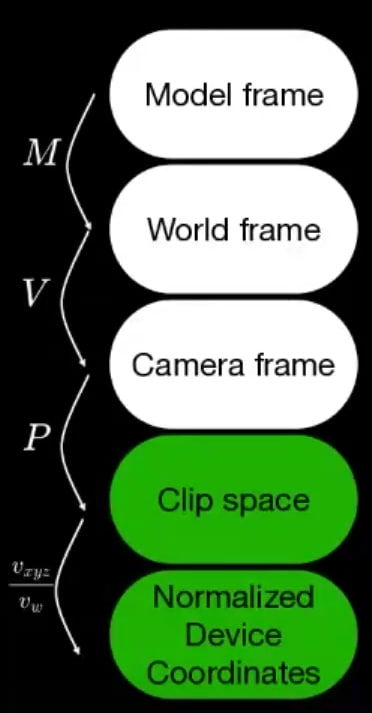</td>
  </tr>
</table>


1.   **Model frame** is the object's coordinate system. The Mesh exists in its own coordinate system, so we need to transform it into the world coordinate system (**World frame**) to place it in the scene.




 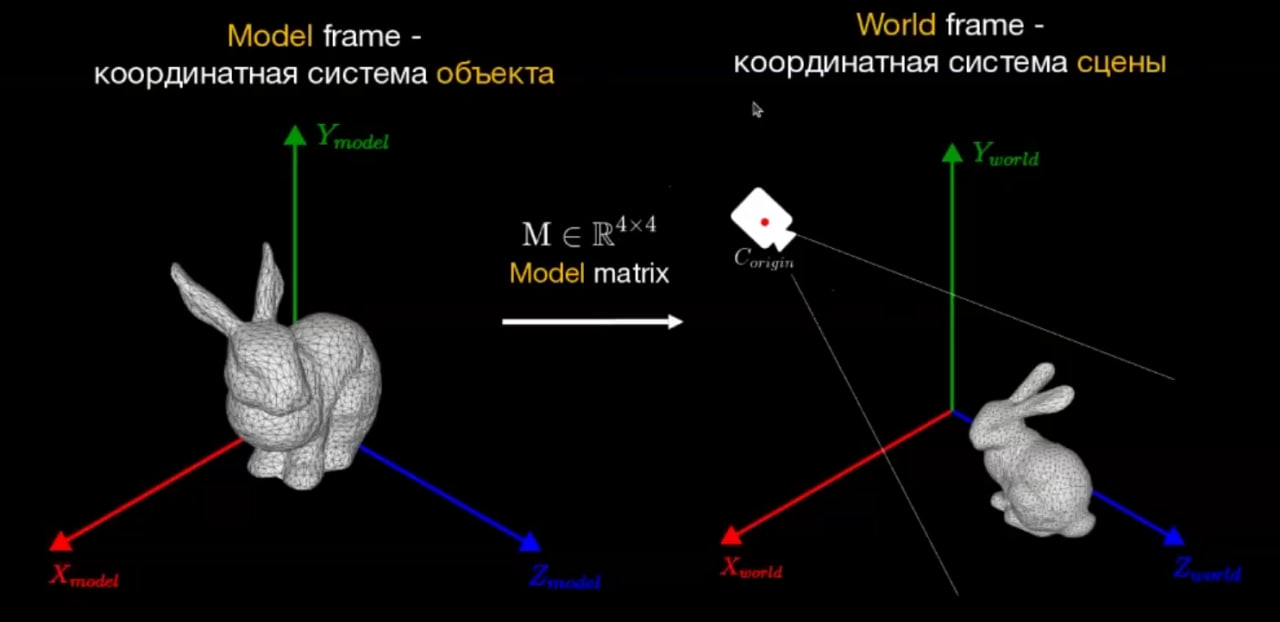

2.   **World frame to Camera frame**: Convert the world coordinate system into the coordinate system of a specific camera (Camera frame).

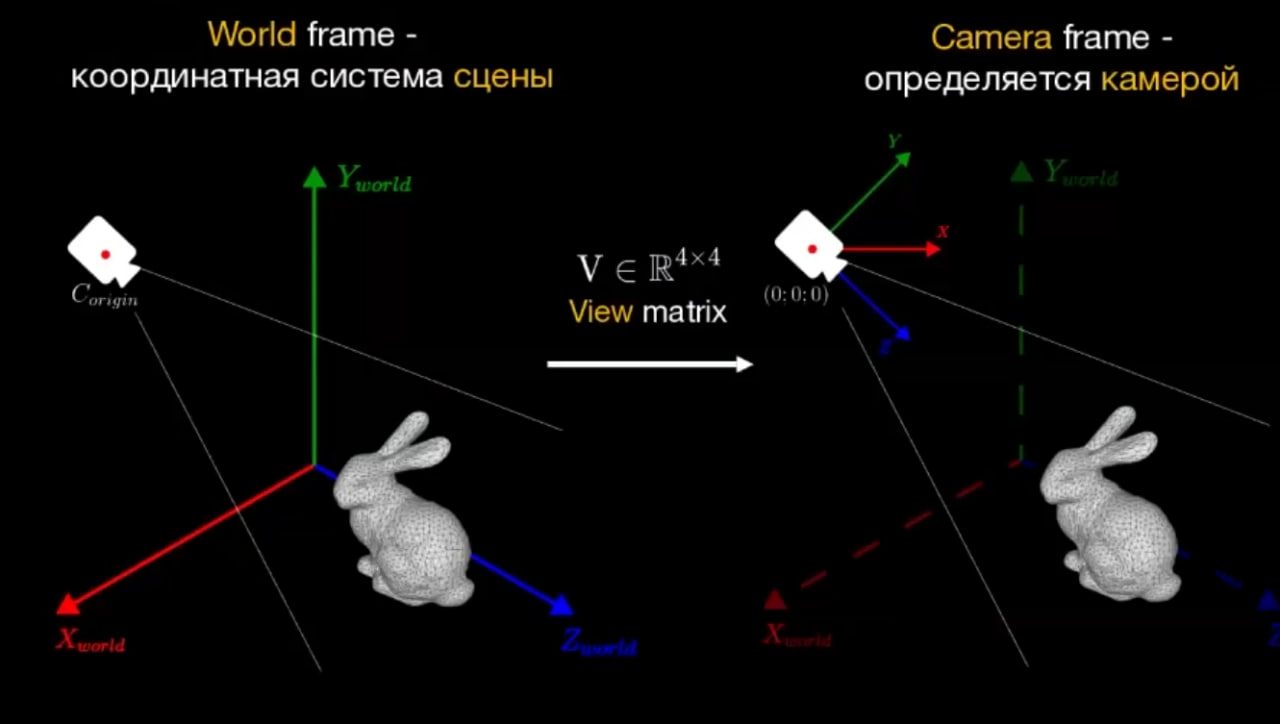

3.    **Camera frame to Clip space**: The Camera frame is still unbounded, so we need to define a finite volume that will be projected onto the camera's projection plane. This is done using the projection matrix, which transforms points from Camera frame to Clip space.

  The volume is defined by a frustum (a truncated pyramid).

  Near plane $A_n B_n C_n D_n$ - the projection screen.

  Far plane $A_f B_f C_f D_f$ - limits visibility.

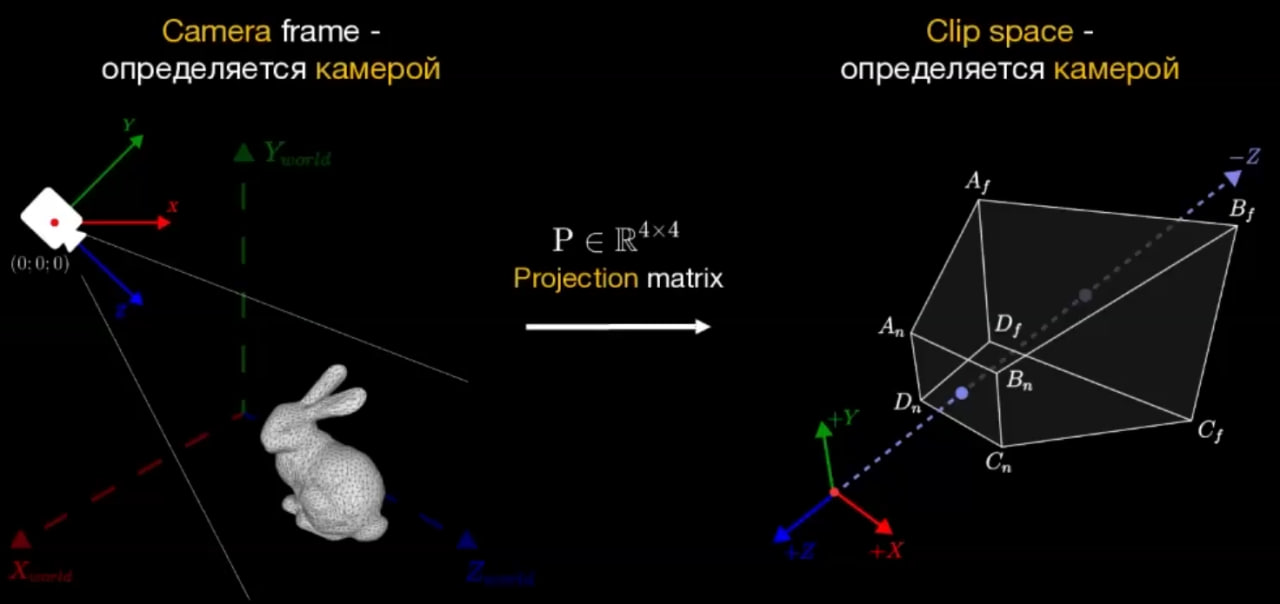

4.    Normalize the frustum into a cube for easier handling. Convert back from homogeneous coordinates to Euclidean coordinates.

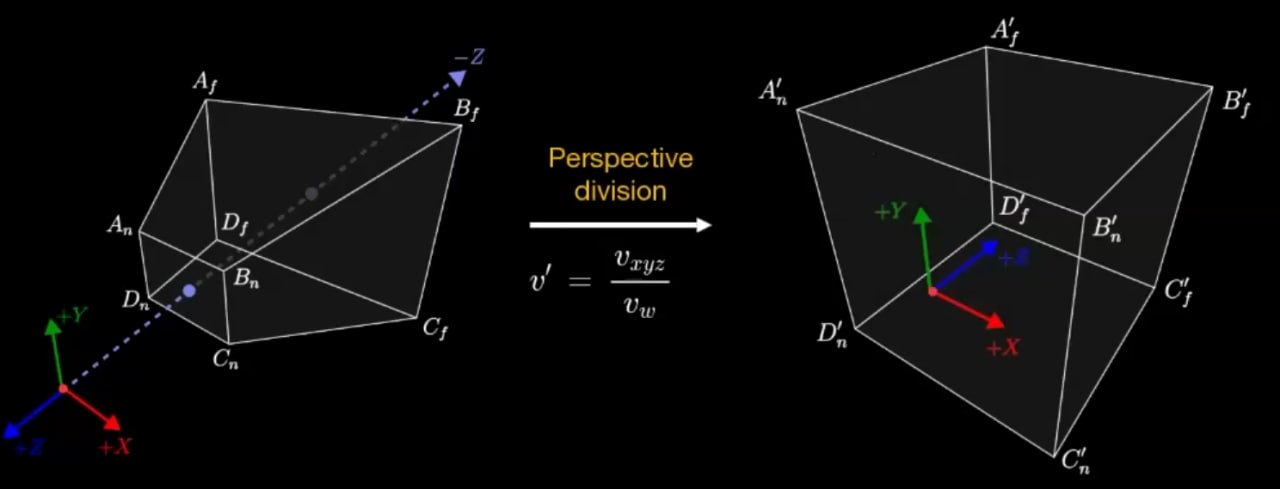

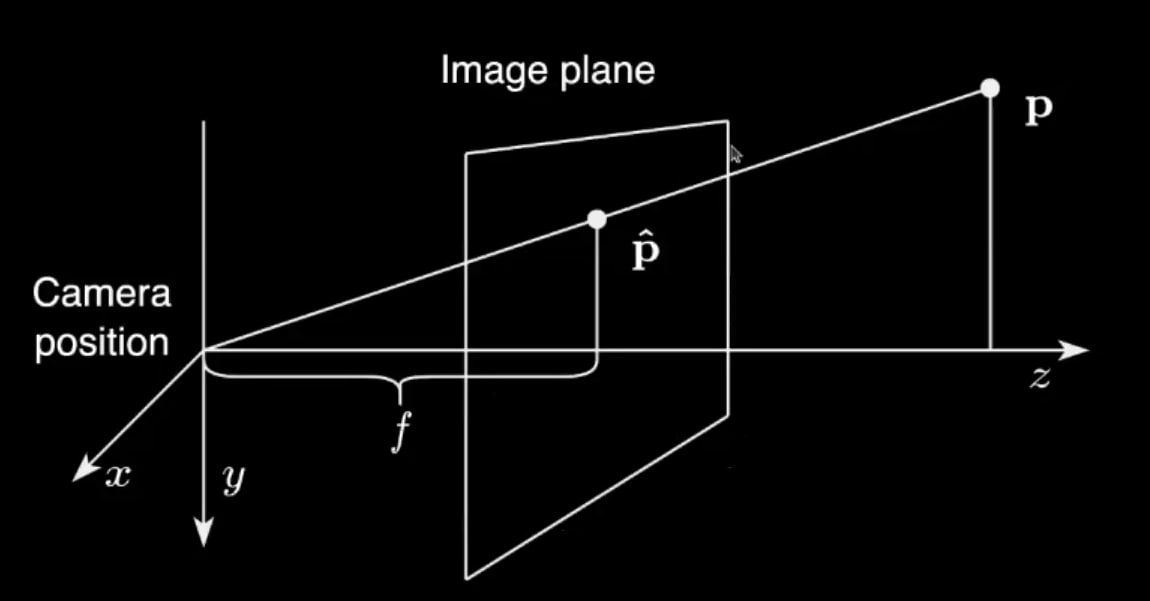

**Pinhole Camera Model**

Pinhole camera is the simplest camera model without lenses, with an infinitely small aperture (the size of the hole through which light enters).

$p$ - a point in the camera's coordinate system.

$\hat{p}$ - the projection of the point onto the image plane.

$f$ - the camera's focal length.

There is a light-sensitive plane — the **Image plane**. Light passes through an infinitely small hole and is projected onto this plane. This results in a perspective projection, where point p is projected along a ray connected to the origin of the coordinate system (the hole through which light enters). The coordinates of point $\hat{p}$ are derived from similar triangles.

All vertex transformation operations are *continuous and differentiable* (only matrix multiplications and scalar divisions).

In [16]:
mvp_matrix = my_camera.get_mvp()  # (b, i, j), b - batch

projected_verts = torch.einsum(
    'nj,bij->bni',
    homogenize_points(my_mesh.verts),
    mvp_matrix
)
projected_verts = projected_verts.contiguous() # we need this for nvdiffrast

In [17]:
assert projected_verts.shape == (1, len(my_mesh.verts), 4), "Projected verts shape mismatch"
assert projected_verts.is_contiguous(), "Projected verts must be contiguous"

This code snippet projects the vertices of a 3D mesh (my_mesh.verts) into 2D space using the MVP (Model-View-Projection) matrix.

`mvp_matrix = my_camera.get_mvp()` - get the MVP matrix from the camera. This is a transformation matrix that combines:
- Model (object transformations)
- View (camera transformations)
- Projection (perspective projection)

The result is vertices in clip space (normalized coordinates, where the visible area is usually [-1,1] in x,y and [0,1] or [-1,1] in z).

### Rasterization

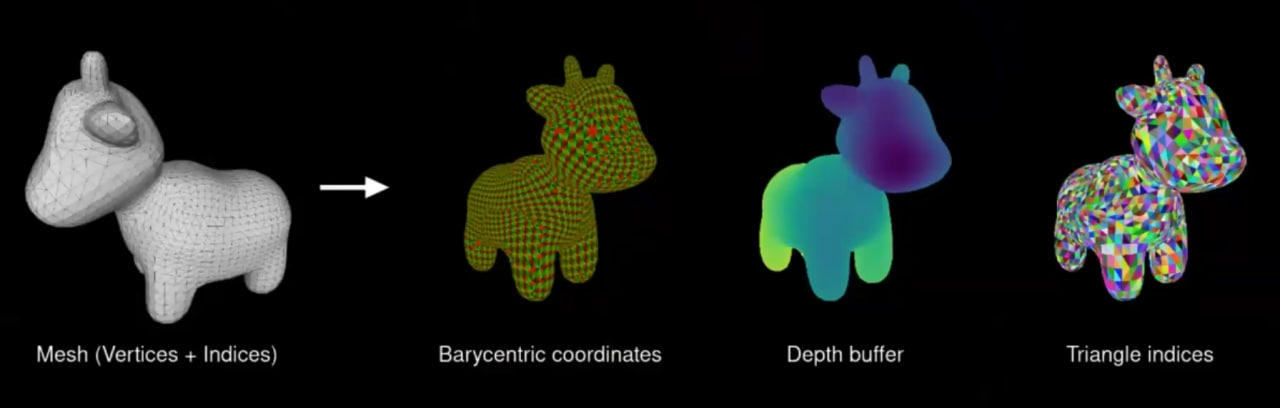

1.    **Input:** A triangular mesh, where each pixel on the screen is assigned at most one triangle.

2.    **Pixel Coverage Test:** Determines whether a pixel is covered by a triangle using **three edge equations.**

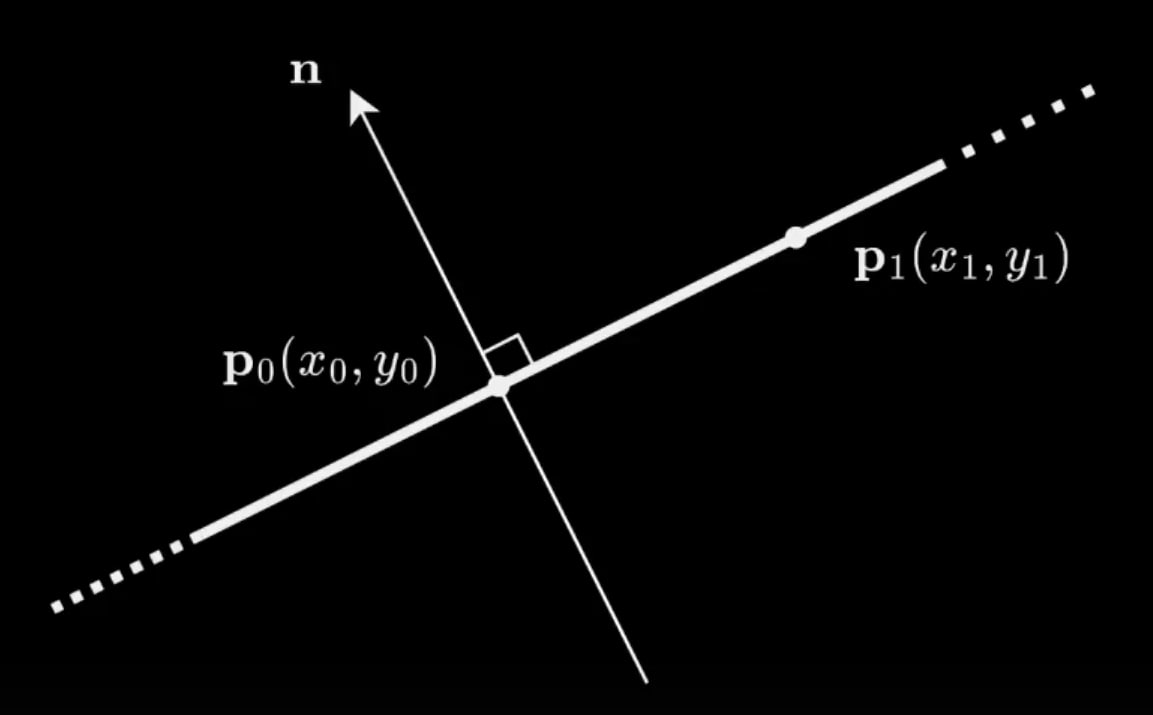


An **edge equation** is a straight line: $$e(x,y) = ax + by + c = det \pmatrix
{x & y & 1 \\
x_0 & y_0 & 1 \\
x_1 & y_1 & 1}$$

This line passes through two vertices $p_0$ and $p_1$. The equation equals zero on the edge itself.

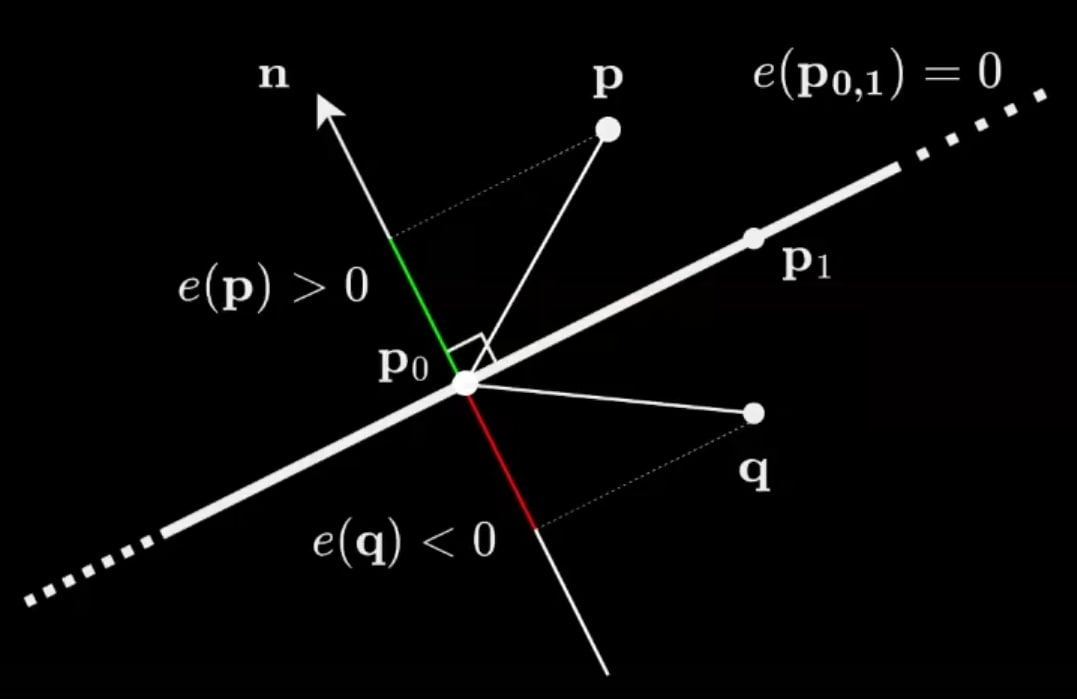

In vector form:$$\color{blue}{e}(\color{orange}p) = n^T(p - p_0)$$

$\color{blue}{e - edge\ function}$

$\color{orange}{p - point}$

$n = \pmatrix{y_0 - y_1 \\ x_0 - x_1}$ - normal to the edge $p_0p_1$

$(p - p_0)$ - vector from vertex $p_0$ to point $p$

The orientation of the normal depends on the order of the vertices. Therefore, all triangles in the Mesh must be defined in the same winding order (either all clockwise or all counterclockwise—mixing is not allowed!).

The function $e(p)$ is signed! It can be expressed in terms of the angle $\phi$ between vectors $(p - p_0)$ and normal $n$:
$$e(p) = ||p_0 - p_1z||\ ||p - p_0||\ cos\color{blue}\phi$$

$$\color{blue}\phi < \frac{\pi}{2} \implies e(p) > 0$$
$$\color{blue}\phi > \frac{\pi}{2} \implies e(p) < 0$$

Thus, $e(p)$ changes sign when crossing the edge $(p_0 - p_1) \implies$ it can be used as an indicator of membership in the half-plane.

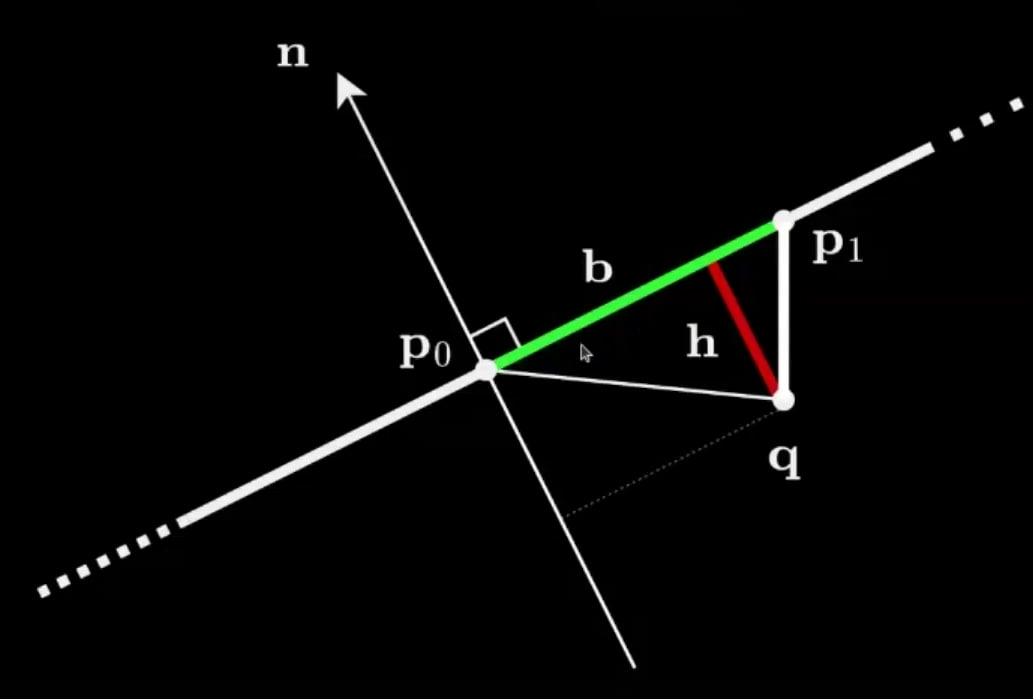


For $△p_0p_1q$:
$$e(p) = ||p_0 - p_1|| \ ||p - p_0|| cos\phi$$

The module $e(p)$ is equal to twice the area of ​​this triangle:

$$|e(p)| = 2 * \frac{1}{2} bh = 2A_{△p_0p_1q}$$

As a result, the $\color{blue}{coverage\ test}$ looks like this:

If all three edge functions are $\color{green}{positive}$ for a point, it lies $\color{green}{inside}$ the triangle.

If at least one is $\color{red}{negative}$, it lies $\color{red}{outside}$, and the triangle does not cover that pixel.

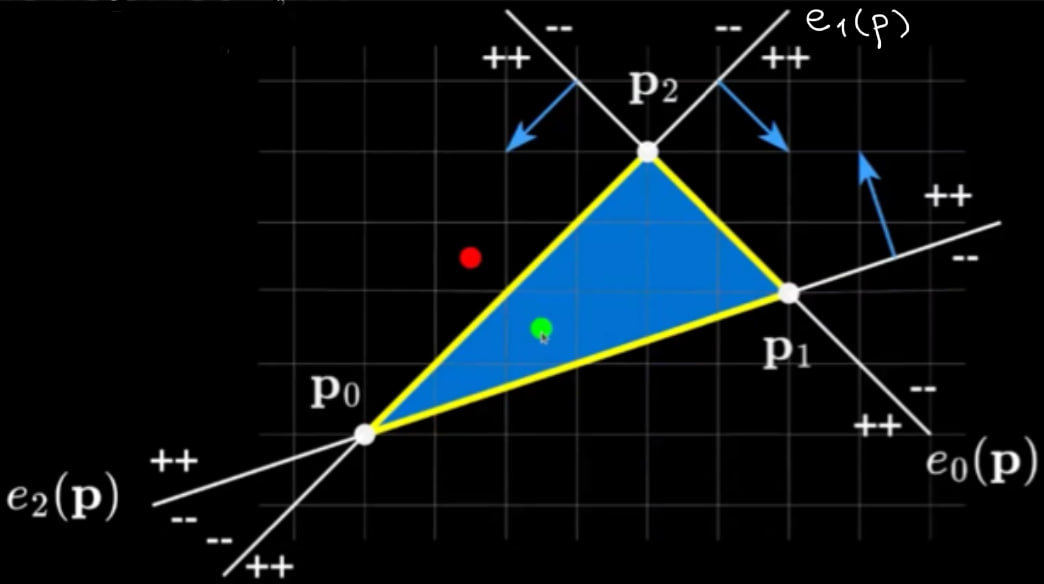


In [19]:
# Initialization of the context of rasterisation execution on GPU using CUDA.
glctx = dr.RasterizeCudaContext()

rast_out, rast_out_db = dr.rasterize(
    glctx,
    projected_verts,
    my_mesh.faces,
    resolution=(512, 512)
)

print(rast_out.shape)

torch.Size([1, 512, 512, 4])


`rast_out` – tensor with barycentric coordinates $(u, v)$, depth $(z)$ and triangle IDs.

`rast_out_db` – derivatives of barycentric coordinates along screen axes ($\frac{du}{dX}, \frac{du}{dY}, \frac{dv}{dX}, \frac{dv}{dY}$).

In [20]:
assert rast_out.shape == (1, 512, 512, 4), "Raster output shape error"
assert rast_out_db.shape == (1, 512, 512, 4), "Raster derivatives shape error"

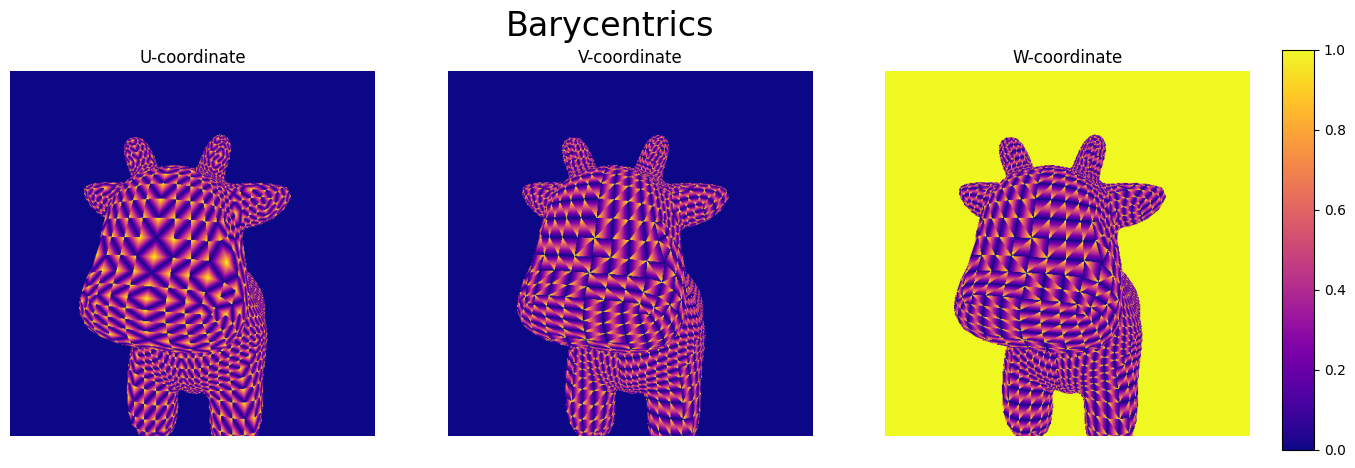

In [21]:
# Visualization of barycentric coordinates with colormap
plt.figure(figsize=(16, 8))
plt.subplot(1, 3, 1)
plt.imshow(rast_out[0, ..., 0].cpu(), cmap='plasma')  # u
plt.title('U-coordinate')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(rast_out[0, ..., 1].cpu(), cmap='plasma')  # v
plt.title('V-coordinate')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow((1 - rast_out[0, ..., 1].cpu() - rast_out[0, ..., 0].cpu()), cmap='plasma')  # w
plt.title('W-coordinate')
plt.axis('off')

plt.suptitle("Barycentrics", fontsize=24, y=0.8)
plt.colorbar(cax=plt.axes([0.92, 0.25, 0.02, 0.5]))
plt.show()

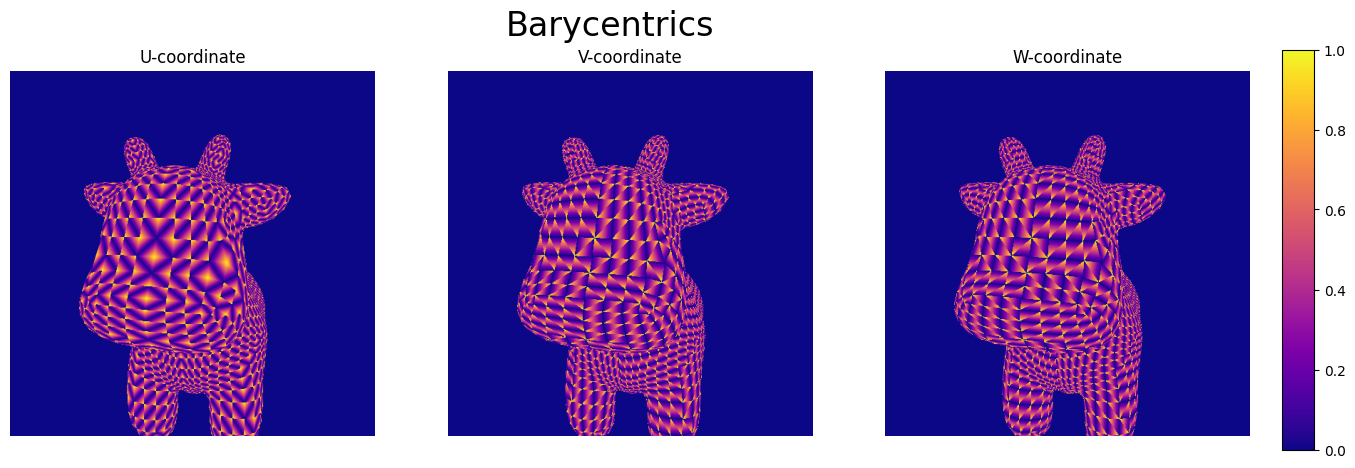

In [22]:
# Small library problem: the background has a triangle index of 0, it has its own color on texture. Add mask.
mask = rast_out[0, ..., 3] != 0  # where triangle_id != 0

assert mask.shape == (512, 512), "Mask shape error"

plt.figure(figsize=(16, 8))
plt.subplot(1, 3, 1)
plt.imshow(rast_out[0, ..., 0].cpu() * mask.cpu(), cmap='plasma')
plt.title('U-coordinate')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(rast_out[0, ..., 1].cpu() * mask.cpu(), cmap='plasma')
plt.title('V-coordinate')
plt.axis('off')

plt.subplot(1, 3, 3)
w = 1 - rast_out[0, ..., 0] - rast_out[0, ..., 1]
plt.imshow(w.cpu() * mask.cpu(), cmap='plasma', vmin=0, vmax=1)
plt.title('W-coordinate')
plt.axis('off')

plt.suptitle("Barycentrics", fontsize=24, y=0.8)
plt.colorbar(cax=plt.axes([0.92, 0.25, 0.02, 0.5]))
plt.show()

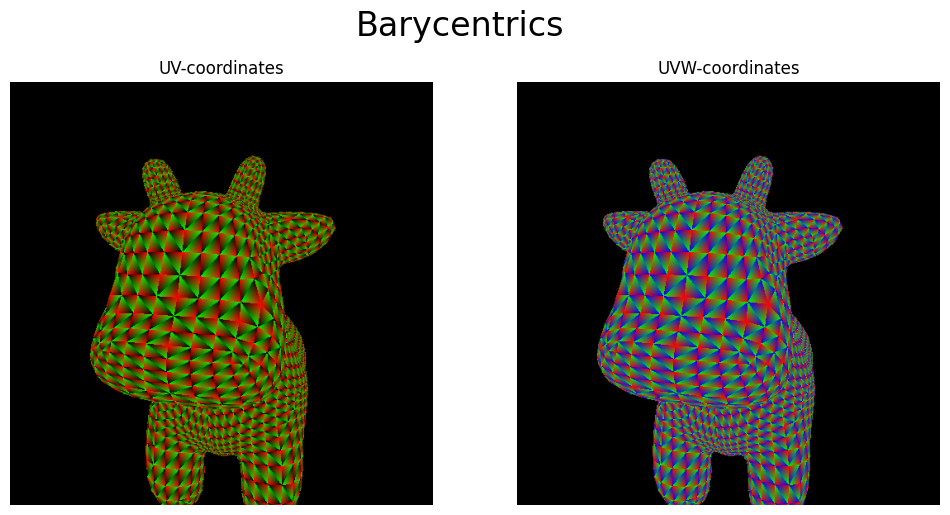

In [23]:
# Combine all of them
mask = rast_out[0, ..., 3] != 0  # where triangle_id != 0

plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
uv = torch.cat([rast_out[0, ..., :2].cpu(), torch.zeros(512, 512, 1)], dim=-1)
plt.imshow(uv.cpu() * mask[..., None].cpu())
plt.title('UV-coordinates')
plt.axis('off')

plt.subplot(1, 2, 2)
w = 1 - rast_out[0, ..., 1] - rast_out[0, ..., 0]
uvw = torch.cat([rast_out[0, ..., :2].cpu(), w[..., None].cpu()], dim=-1)
plt.imshow(uvw.cpu() * mask[..., None].cpu())
plt.title('UVW-coordinates')
plt.axis('off')

plt.suptitle("Barycentrics", fontsize=24, y=0.85)
plt.show()

3.    **Depth Test**: Sorts triangles by depth buffer.

Only the $\color{blue}{closest}$ triangle (by depth) is rasterized.

**Depth buffer** is a matrix the size of the image, storing the depth of the nearest triangle for each pixel.

At this stage, the depth buffer is computed: all triangles are projected, and we check which pixels they cover (e.g., in the image, the blue one is closer because its distance $z_1$ is less than $z_2$, so it is selected for that pixel).

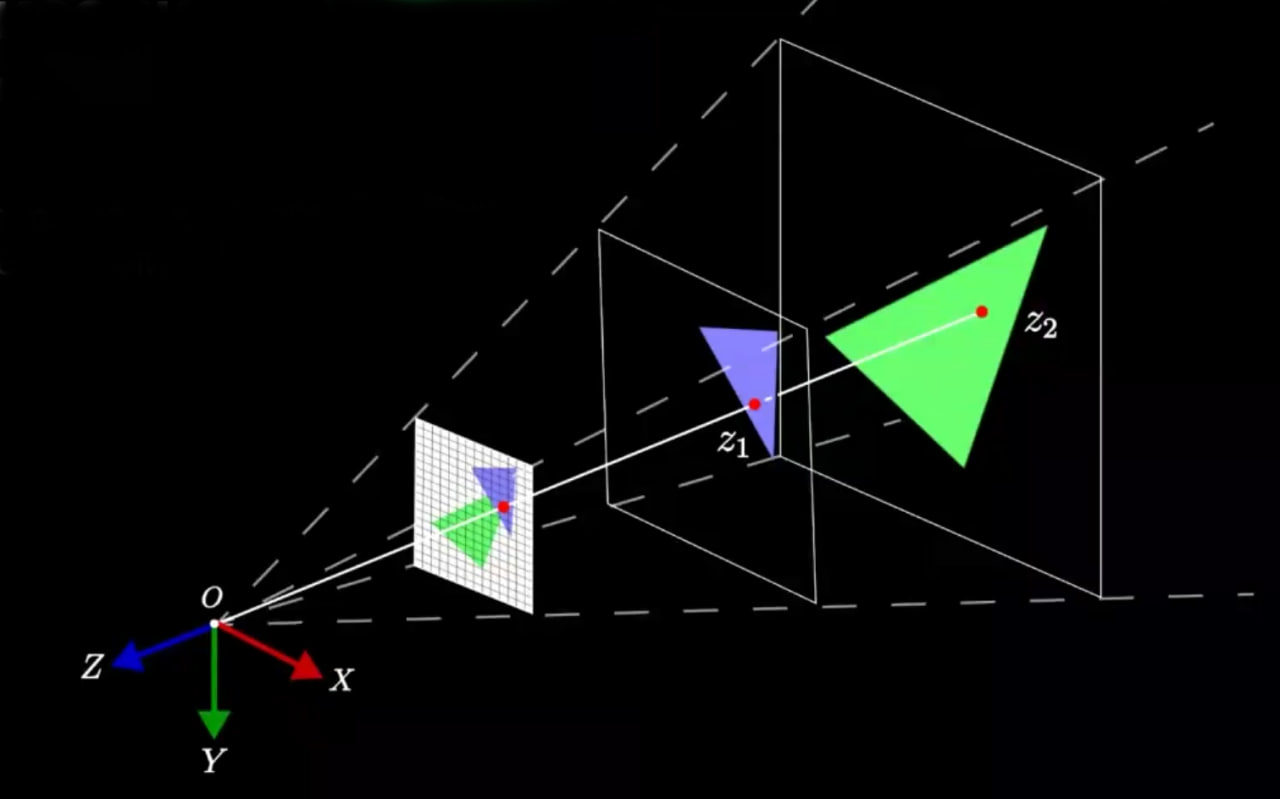


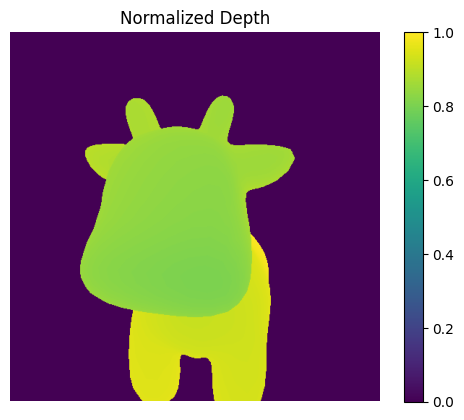

In [25]:
# Normalized depth value: z / w (w from homogeneous coordinates)
depth = rast_out[0, ..., 2].cpu()

assert depth.min() != depth.max(), "Depth values not normalized"

# Convert the depth values to [0,1].
depth_normalized = (depth - depth.min()) / (depth.max() - depth.min())
plt.imshow(depth_normalized)
plt.title('Normalized Depth')
plt.axis('off')
plt.colorbar()
plt.show()

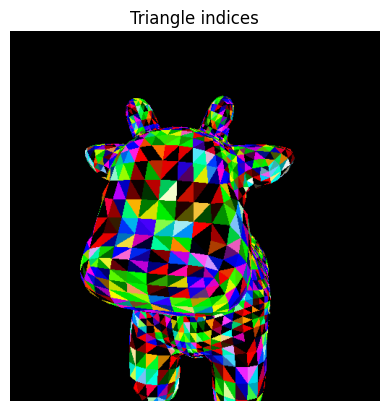

In [32]:
# triangle ids are integers, let's paint them with unique color
triangle_ids = rast_out[0, ..., 3]
triangle_ids = torch.stack([
    (123 * triangle_ids).sin(),
    (345 * triangle_ids).sin(),
    (678 * triangle_ids).sin(),
], dim=-1).clip(0., 1.).cpu()

plt.imshow(triangle_ids)
plt.title('Triangle indices')
plt.axis('off')
plt.show()

4.    **Barycentric Coordinates:** For each pixel, barycentric coordinates on the triangle are computed (along with their screen-space derivatives, optionally).

We want to know where a specific pixel lies inside the triangle being rasterized. For this, we use barycentric coordinates.

**Definition** of barycentrics $u, v, w$:

1.   $u, v, w > 0$
2.   $u + v + w = 1$

$$u(x,y) = \frac{a_0}{A_△} = \frac{e_0(x,y)}{2A_△}$$

$$v(x,y) = \frac{a_1}{A_△} = \frac{e_1(x,y)}{2A_△}$$

$$w = 1 - u - v$$

$a_0 = S_{△pp_1p_1}$,  $A_△ = S_{△p_0p_1p_1}$

The triangle area $A_△$ does not depend on $p$

Note that barycentric coordinates depend *continuously and differentiably* on the mesh vertices.

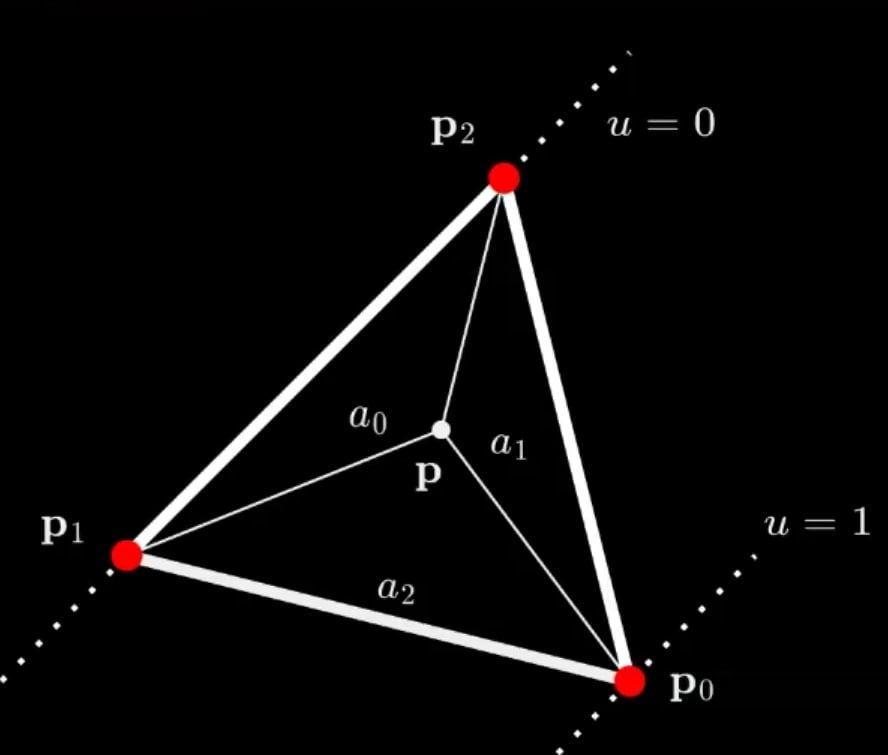


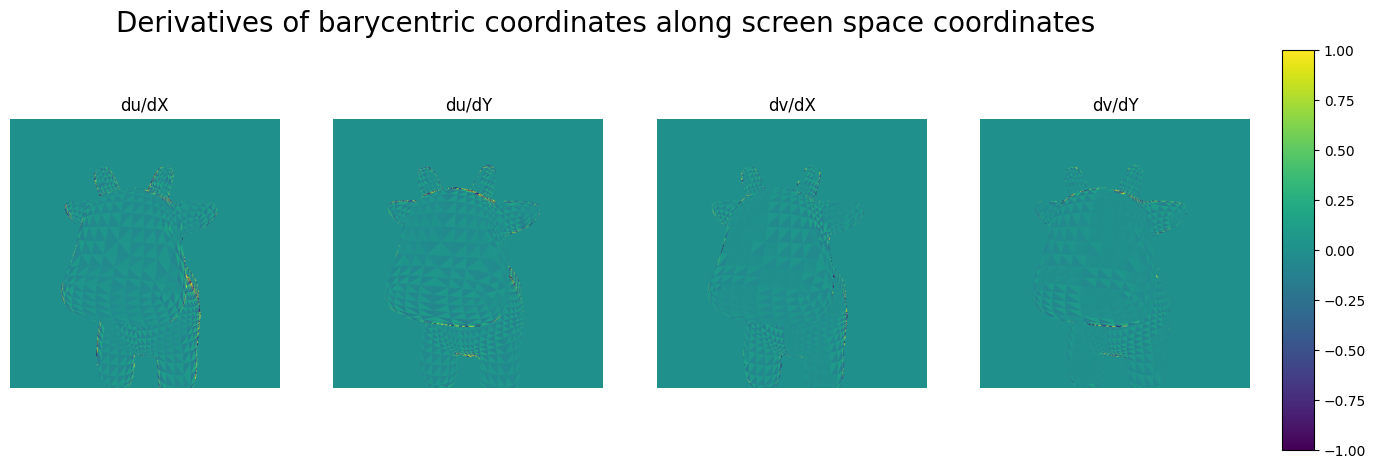

In [24]:
# rast_out_db - derivatives of barycentric coordinates along the x and y screen space coordinates (du/dX, du/dY, dv/dX, dv/dY)
# (for scale of triangles relative to pixels)

mask = rast_out[0, ..., 3] != 0  # where triangle_id != 0

plt.figure(figsize=(16, 8))

plt.subplot(1, 4, 1)
plt.imshow(rast_out_db[0, ..., 0].cpu(), vmin=-1, vmax=1)
plt.title('du/dX')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(rast_out_db[0, ..., 1].cpu(), vmin=-1, vmax=1)
plt.title('du/dY')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(rast_out_db[0, ..., 2].cpu(), vmin=-1, vmax=1)
plt.title('dv/dX')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(rast_out_db[0, ..., 3].cpu(), vmin=-1, vmax=1)
plt.title('dv/dY')
plt.axis('off')

plt.suptitle("Derivatives of barycentric coordinates along screen space coordinates ", fontsize=20, y=0.8)
plt.colorbar(cax=plt.axes([0.92, 0.25, 0.02, 0.5]))
plt.show()

### Texture interpolation (example of attribute)

We need a way to determine attributes (e.g., normals, texture coordinates) inside triangles when we know their values at the vertices.

Now that we have barycentric coordinates, how can we determine the attribute value for a specific pixel?

<center>
$p_0, p_1, p_2$ -oints on the screen

$A_0, A_1, A_2$ - attributes at these points (assumed to vary linearly in space)

**Naive interpolation:**

$$A = uA_0 + vA_1 + (1 - u - v)A_2$$



However, this naive interpolation leads to distortions due to perspective projection. In the second picture you can see that the texture is not applied correctly:

<table>
  <tr>
    <td>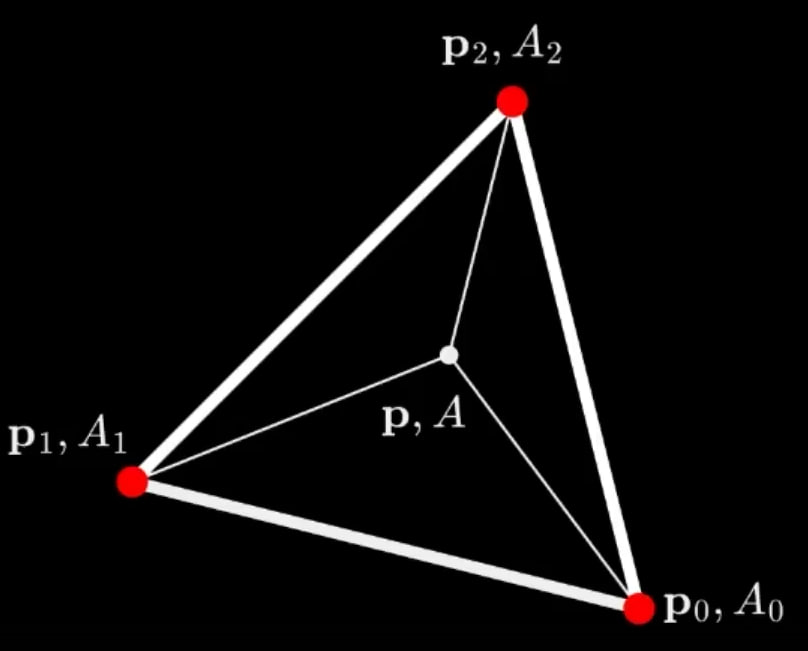</td>
    <td>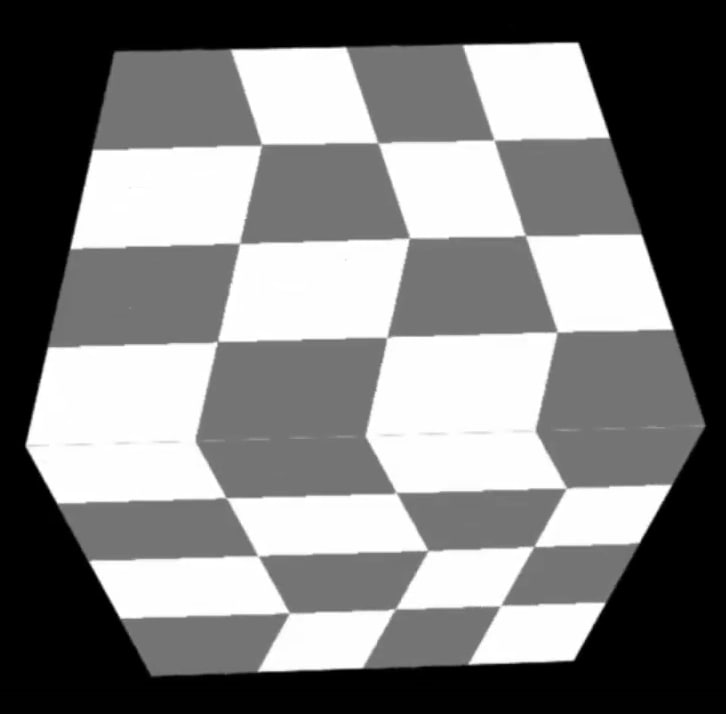</td>
  </tr>
</table>

Points $p_1, p_2, p$ are projected onto the screen as $s_1, s_2, s$

We know the linear interpolation coefficient $t$ in screen space (barycentric coordinates).

Let's consider a degenerate case - a line. $p_1, p_2$ are the vertices of a degenerate triangle. We have a linear dependence in space: $p = (1 - q)p_1 + qp_2$

We calculated $t$ and $1 - t$, and $\frac{t}{1-t} ≠ \frac{q}{1-q} \implies$ for correct interpolation we need to calculate $q$ and $1-q$

By similarity of triangles: $$\frac{p^1_x}{p^1_z} = \frac{s^1_x}{f}, \frac{p_x}{p_z} = \frac{s_x}{f}, \frac{p^2_x}{p^2_z} = \frac{s^2_x}{f}$$


Interpolation: $
\begin{cases}
s_x = s^1_x + t(s^2_x - s^1_x) \\
p_x = p^1_x + q(p^2_x - p^1_x) \\
p_z = p^1_z + q(p^2_z - p^1_z)
\end{cases}
\implies q = \frac{tp^1_z}{tp^1_z + (1 - t)p^2_z}$ - зависит от глубины

We get that the interpolation coefficient in the space $\color{red}{nonlinearly}$ depends on the coefficient in the plane!

Points $p$ are in the clip-space, i.e. $p_z$ is the $w$ coordinate in homogeneous coordinates

<table>
  <tr>
    <td>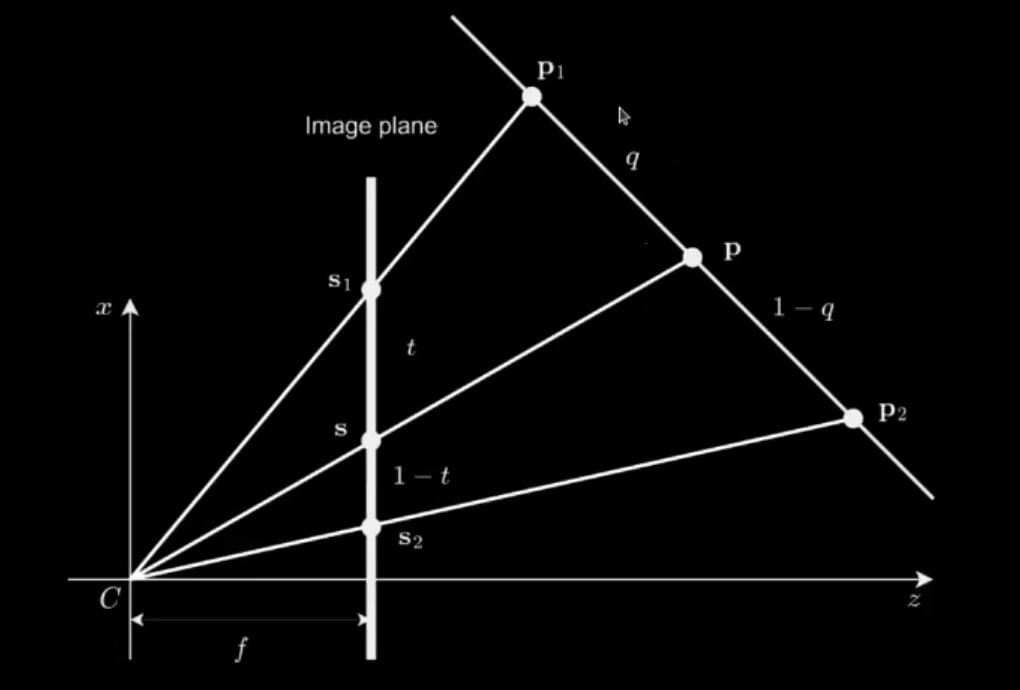</td>
    <td>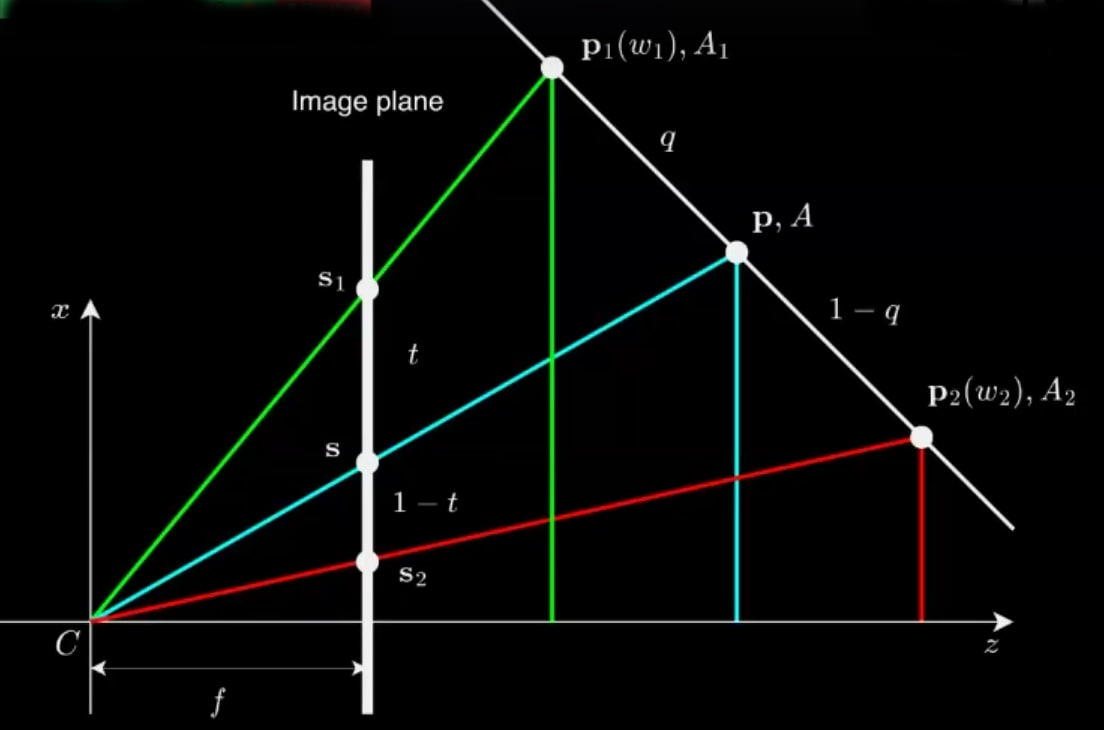</td>
  </tr>
</table>

To correctly interpolate attributes in clip-space:
$$A(p) = A_1 + q(A_2 - A_1)$$

$$q = \frac{tw_1}{tw_1 + (1 - t)w_2}$$

$$A(p) = \frac{\frac{A_1}{w_1} + t(\frac{A_2}{w_2} - \frac{A_1}{w_1})}{\frac{1}{w_1} + t(\frac{1}{w_2} - \frac{1}{w_1})}$$

$$A(p) = \frac{lerp(\frac{A}{w}, t)}{lerp(\frac{1}{w}, t)}$$

$lerp()$ - linear interpolation

To correctly interpolate attributes, it is necessary to use a spatial smoothing coefficient.

Before: $A(p) = A_1\color{green}{(1-t)} + A_2\color{gold}{t} = A_1\color{green}{\frac{1-t}{1-t+t}} + A_2\color{gold}{\frac{t}{1-t+t}}$

After: $A(p) = A_1\color{green}{\frac{\frac{1-t}{w_1}}{\frac{1-t}{w_1} + \frac{t}{w_2}}} + A_2\color{gold}{\frac{\frac{t}{w_2}}{\frac{1-t}{w_1} + \frac{t}{w_2}}}$

But, for prospective intropolation, it is possible to correct flat barycentrics (we correct them once and then always interpolate attributes linearly) and use them for linear interpolation.

By analogy $$\hat{u}(x,y) = \frac{\frac{u}{w_0}}{\frac{u}{w_0} + \frac{v}{w_1} + \frac{1 - u - v}{w_2}}$$

$$\hat{v}(x,y) = \frac{\frac{v}{w_0}}{\frac{u}{w_0} + \frac{v}{w_1} + \frac{1 - u - v}{w_2}}$$

$\implies \hat{u}(x,y) = \frac{\frac{e_0(x,y)}{w_0}}{\frac{e_0(x,y)}{w_0} + \frac{e_1(x,y)}{w_1} + \frac{e_2(x,y)}{w_2}}$ $\begin{cases}
Both\ numerator\ and\ denominator\ depend\ on\ the\ position\ of\ p \\
Barycentrics\ after\ correction\ linearly\ interpolate\ attributes
\end{cases}$

We have obtained a universal formula for perspectively correct interpolation of attributes. With its help, we have learned to correct flat barycentrics for correct linear interpolation without the need to use a universal formula.

In [35]:
# interpolated attribute & derivatices
texc, texd = dr.interpolate(
        my_mesh.uvs[None, ...],
        rast_out,
        my_mesh.faces,
        rast_db=rast_out_db,
        diff_attrs='all'
)

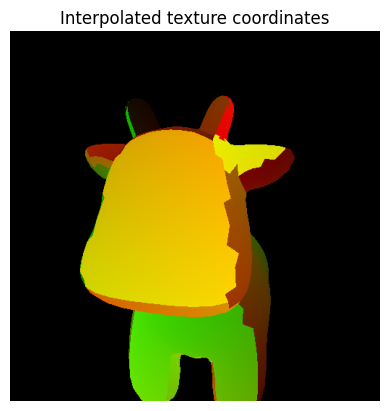

In [36]:
plt.imshow(torch.cat([texc[0, ..., :2].cpu(), torch.zeros(512, 512, 1)], dim=-1))
plt.title('Interpolated texture coordinates')
plt.axis('off')
plt.show()

# Texturing

Besides attributes that change linearly, there are those that cannot be described this way, for example, color.

Color can be a high-frequency function.

A $\color{blue}{texture}$ is a $\color{blue}{2D\ image}$ where each pixel defines the value of an attribute (such as color) for some point on a mesh.

During texturing, the value is fetched from this buffer using $\color{blue}{texture coordinates}$. The texture coordinates themselves are a linear attribute.


*   Texture coordinates are defined for each vertex of the mesh.
*   They are described by two normalized coordinates (UV or ST): $$(s_i, t_i) \in [0; 1]^2$$
*   To assign texture coordinates to a mesh, we perform UV unwrapping.
*   To determine the color for each pixel: $\color{gold}{First,\ interpolate\ the\ texture\ coordinates\ across\ the\ triangle}$, $\color{green}{Then,\ sample\ the\ texture\ using\ these\ interpolated\ coordinates.}$

However, if we do this naively, aliasing artifacts (such as shimmering or moiré patterns) will appear.

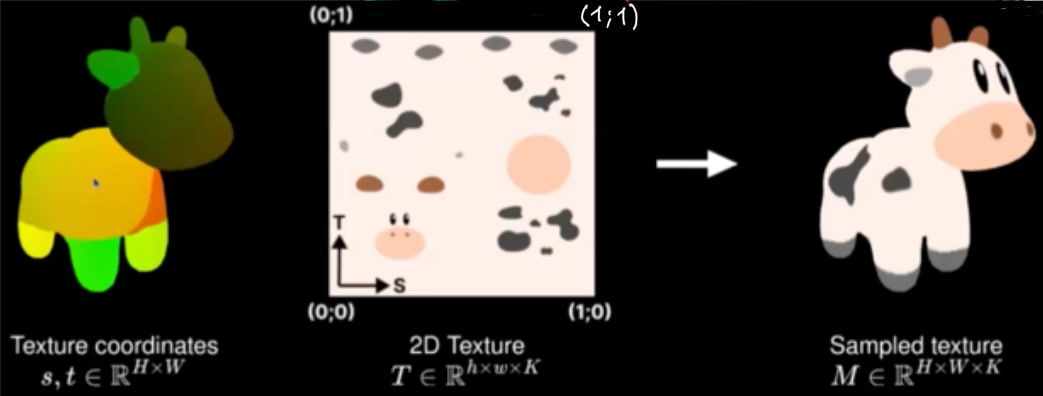

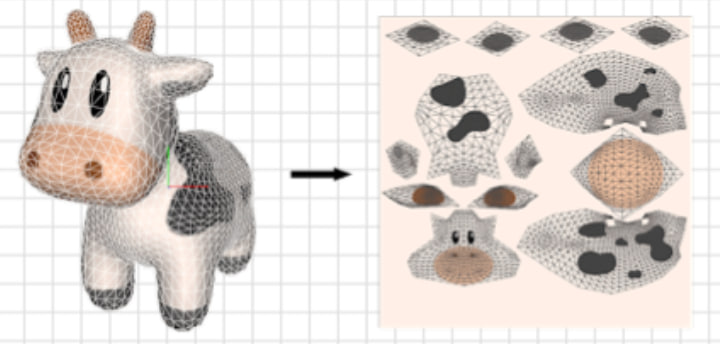

In fact, a pixel on the screen does not correspond to a $\color{red}{single\ point}$ on the texture, it covers an $\color{blue}{entire\ region}$.
Thus, we should theoretically compute the integral of the texture over that region to get the correct color.

But instead, we take a single-point estimate (nearest-neighbor or bilinear filtering) $\implies$ it leads to high variance.

<table>
  <tr>
    <td>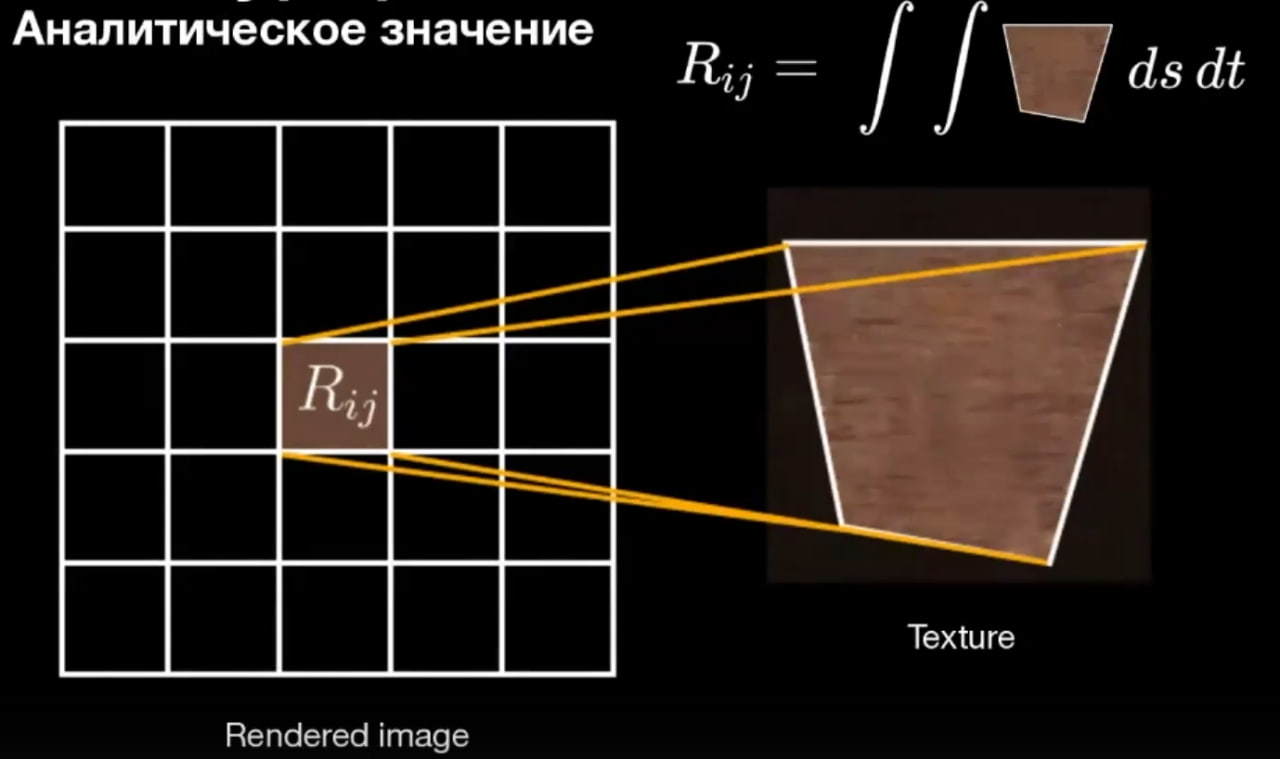</td>
    <td>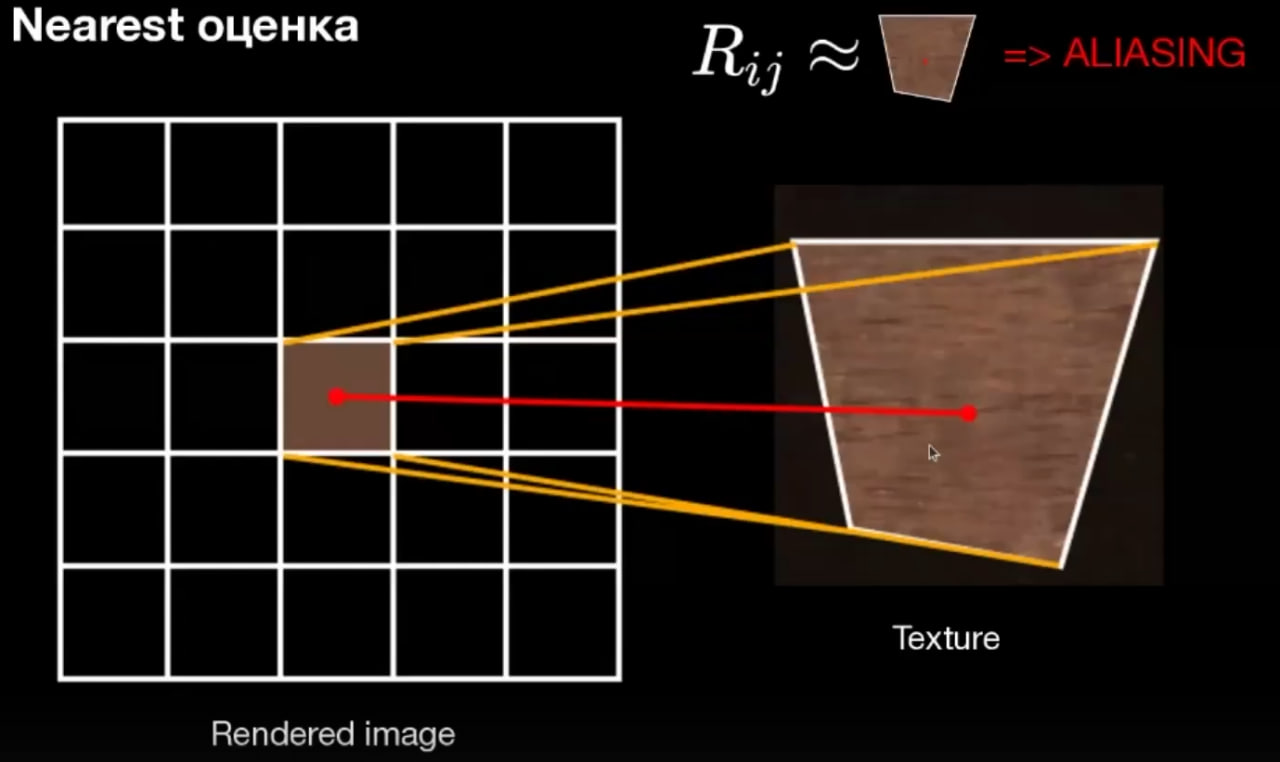</td>
  </tr>
</table>

$\color{red}{How\ to\ solve\ this?}$

$\color{blue}{Intuition}$: ч The farther a pixel is from the camera, the larger the area it covers on the texture

$\color{blue}{Idea}$: pre-integrate textures by areas depending on the pixel size on the texture and take this into account when taking the color

Since exact integration is expensive, we use $\color{blue}{MIP\ levels}$

*   $\color{blue}{MIP\ levels}$ are constructed by $\color{blue}{averaging\ pixels\ over\ areas}$ multiple of 2
*   $\color{blue}{Logarithm\ of\ area\ size\ (power\ of\ two)}$ of averaging determines the MIP level

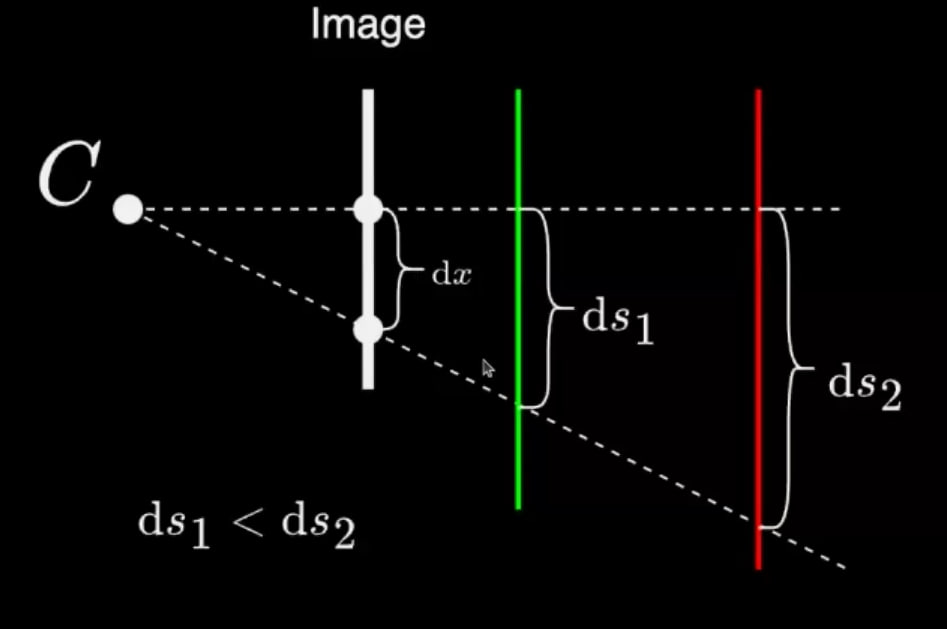

In fact, we prefer to calculate the integral over some areas of the texture:

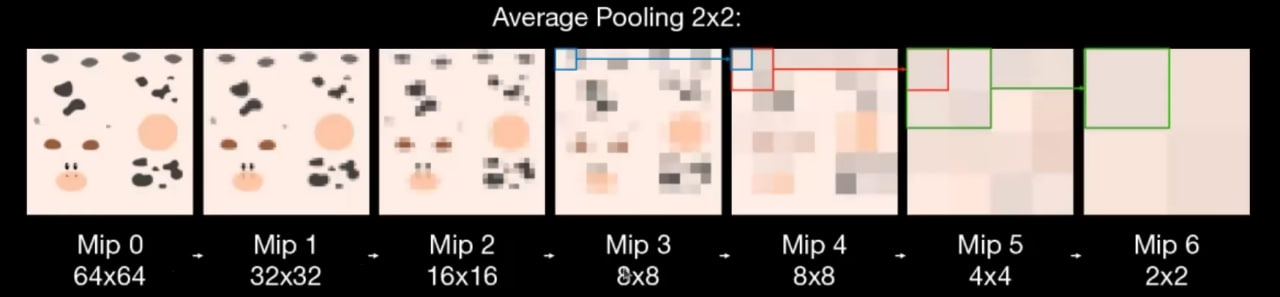

How do you know how much area 1 pixel covers?

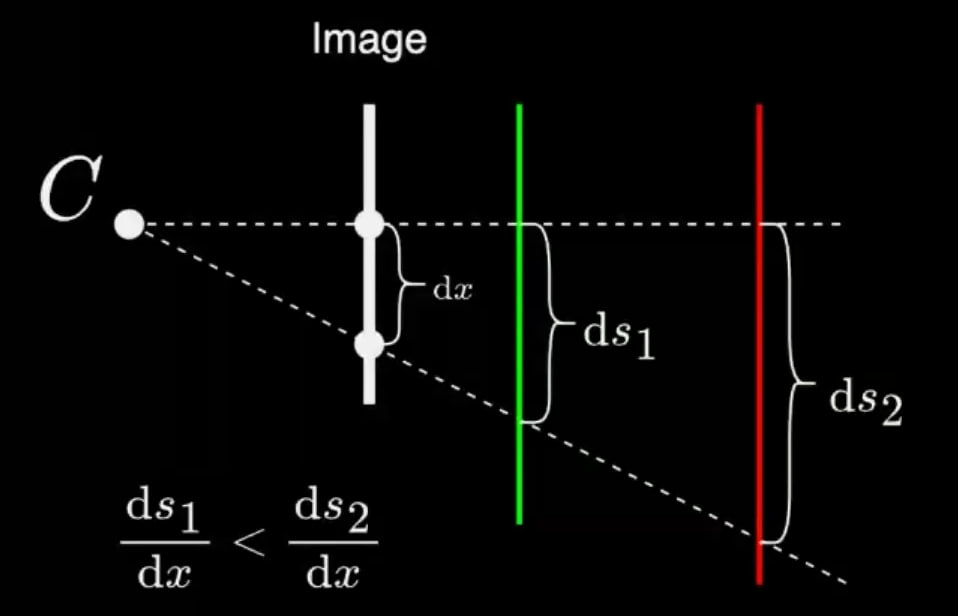

$\color{blue}{Key\ Idea}$: The farther an object is from the camera C, the faster the texture coordinates change relative to screen space. (i.e. we go through a larger part of the texture on the distant object in one step than on the near one)

Since the rays from the camera are divergent, when a pixel is shifted, $\color{blue}{the\ value\ of\ the\ texture\ coordinates\ changes\ less}$ if the $\color{blue}{triangle\ is\ close}$, and $\color{green}{strongly}$ - if $\color{green}{far}$.

$\color{blue}{IDEA}$: Use the derivatives of texture coordinates by screen coordinates to calculate the MIP level

This can be done analytically - screen-space derivatives of texture coordinates are needed: $J = \pmatrix {\frac{ds}{dx} & \frac{ds}{dy} \\ \frac{dt}{dx} & \frac{dt}{dy}}$

$s, t$ are interpolated texture coordinates:
$$s = u(x,y)s_1 + v(x,y)s_2 + (1 - u(x,y) - v(x,y))s_3$$

To calculate their derivatives $\color{blue}{the\ derivatives\ of\ barycentrics}$ with respect to screen-space coordinates $(x,y)$ are needed. $\color{blue}{They\ are\ calculated\ by\ differentiating\ perspective\ correct\ barycentrics\ analytically.}$

$J$ describes how quickly texture coordinates $s, t$ change relative to screen coordinates $(x,y)$

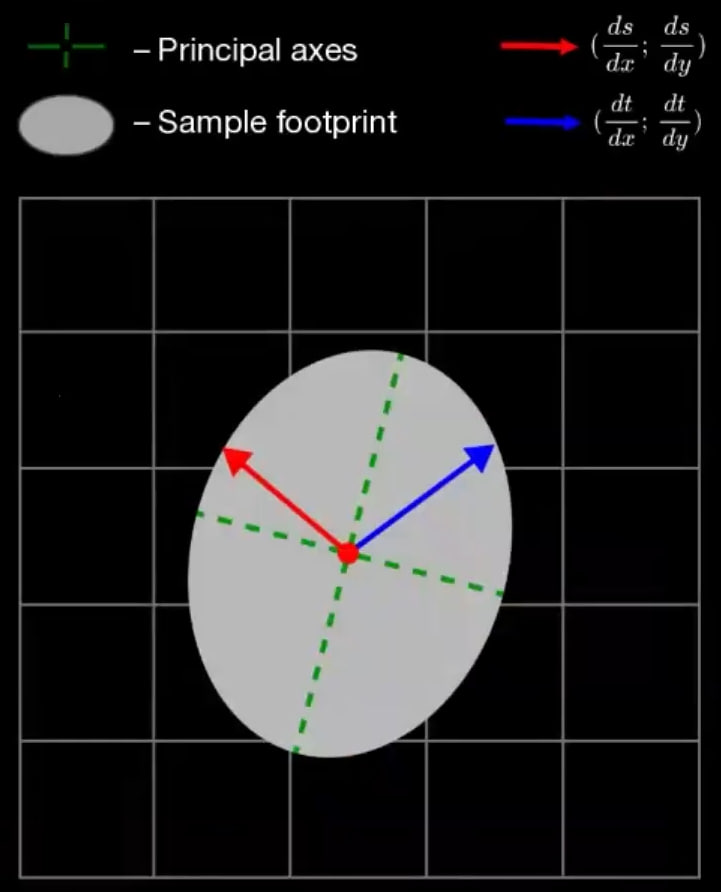

Place $J$ in $SVD$

$\color{blue}{Sample\ footprint}$: shows how the texture area affects one screen pixel. It is formed by transforming the matrix $J$ of the unit circle ("ideal case", when one screen pixel corresponds to one texture pixel)

Singular values ​​$\sigma_1$ and $\sigma_2$ are the lengths of the main axes of the ellipse

Determining the desired MIP level is the task of calculating the $\color{blue}{largest\ singular\ value}$ (the length of the largest axis - eigenvector): $$w = log_2\sigma_1(J)$$

The largest singular value is sought from the equation: $$det(J^TJ - \lambda I) = 0$$
Analytical solution:
$$A = \left(\frac{ds}{dx} \right)^2 + \left(\frac{dt}{dx} \right)^2$$

$$B = \left(\frac{ds}{dy} \right)^2 + \left(\frac{dt}{dy} \right)^2$$

$$C = \frac{ds}{dx} \frac{ds}{dy} + \frac{dt}{dx} \frac{dt}{dy}$$

$$w = \frac{1}{2} log_2 \left[\frac{A+B}{2} + \sqrt{\frac{1}{4}(A - B)^2 + C^2} \right]$$

Each next mip-level reduces the resolution by 2 times ($log_\color{red}{2}(...)$)

But $w$ is a non-integer index, so $\color{blue}{trilinear\ interpolation}$ is used:

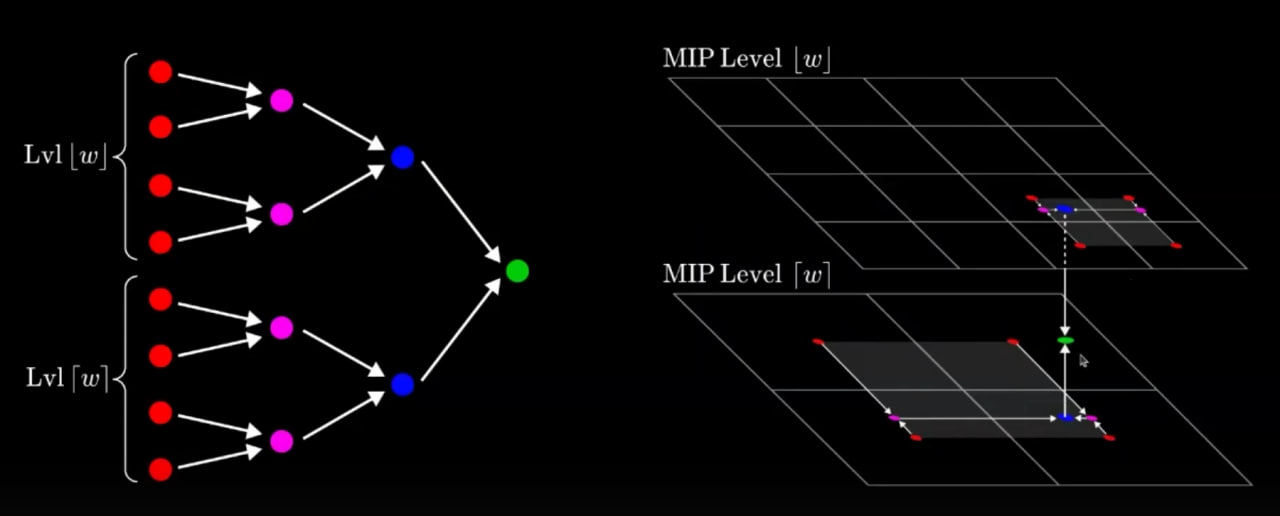

🔴 - pixel value

🟢 - result

$→$ - linear interpolation

This not only allows you to remove ripples, but also allows the derivative to flow better over the structure.

Let's create a random texture and put it on model.

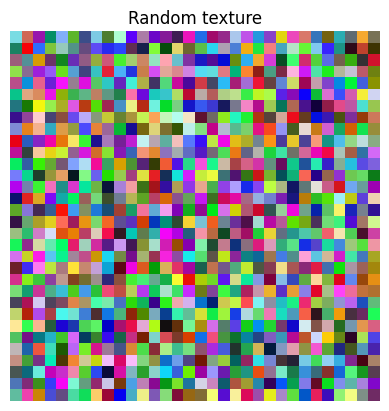

In [33]:
texture = torch.rand(32, 32, 3, device=torch.device('cuda:0'))

plt.imshow(texture.cpu())
plt.title('Random texture')
plt.axis('off')
plt.show()

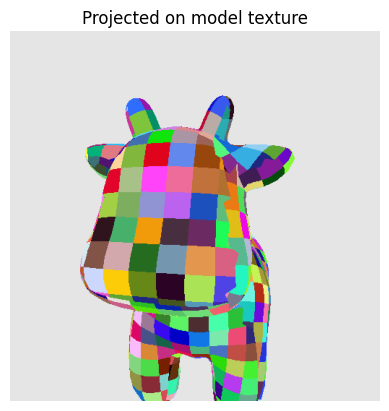

In [37]:
projected_texture = dr.texture(
        texture[None, ...],
        texc,
        texd,
        filter_mode='nearest',
        max_mip_level=9
)

image = projected_texture
mask = torch.clamp(rast_out[..., -1:], 0, 1)
image = torch.where(mask == 1, projected_texture, torch.tensor(0.9))

plt.imshow(image[0].cpu())
plt.title('Projected on model texture')
plt.axis('off')
plt.show()

### Shading

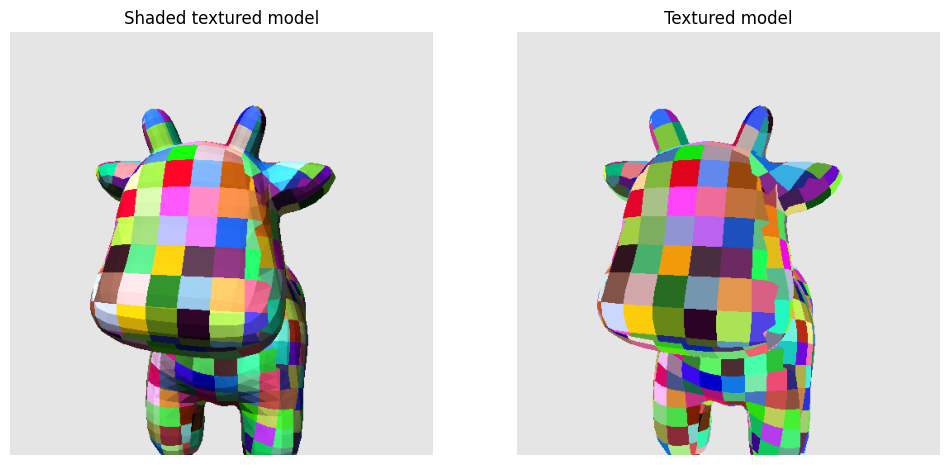

In [38]:
triangle_ids = (rast_out[..., 3].clamp(1.) - 1.).to(torch.long)
normals = my_mesh.normals[triangle_ids]
light_dir = torch.tensor([0., 1., -1.], device=torch.device('cuda:0'))
ligtt_dir = light_dir / light_dir.norm()

diffuse_coefficient = (normals * light_dir).sum(-1, keepdim=True).clamp(0.3)
shaded_image = (
        diffuse_coefficient * projected_texture
).clamp(0., 1.)
mask = torch.clamp(rast_out[..., -1:], 0, 1)
shaded_image = torch.where(mask == 1, shaded_image, torch.tensor(0.9))

plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.imshow(shaded_image[0].cpu())
plt.title('Shaded textured model')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image[0].cpu())
plt.title('Textured model')
plt.axis('off')

plt.show()

## Optimization

It seems like we've already learned how to build something, but now let's try to optimize it all.

The **Visibility gradients** problem

Let's consider a simple problem of optimizing a triangle for a template:

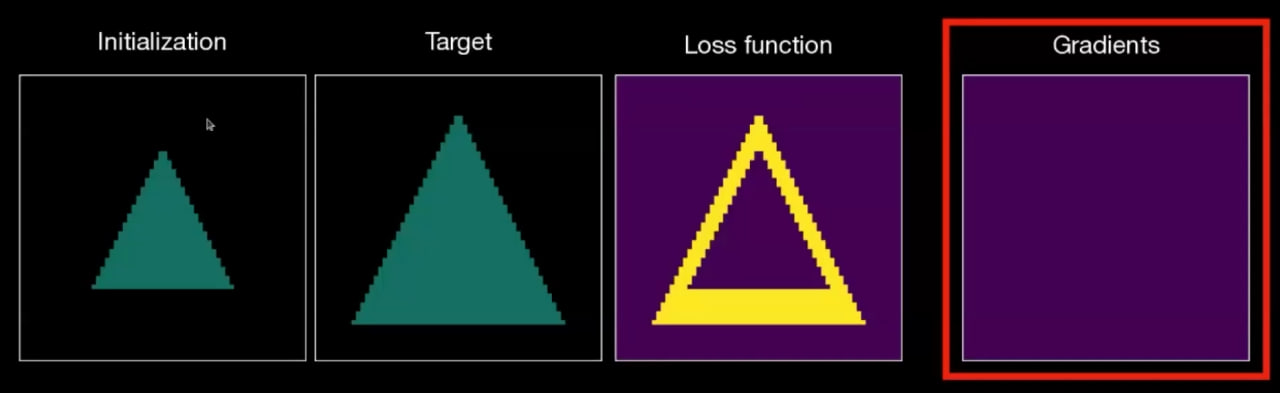

As we can see, the loss function is non-zero, but the optimization does not work because the gradients are 0.

Why are the gradients 0? The triangle is defined by a discrete mask: inside the triangle - value 1, outside - 0. We have a piecewise constant function $\implies$ gradient = 0

The silhouette edges of the triangle create sharp jagged edges in the image:

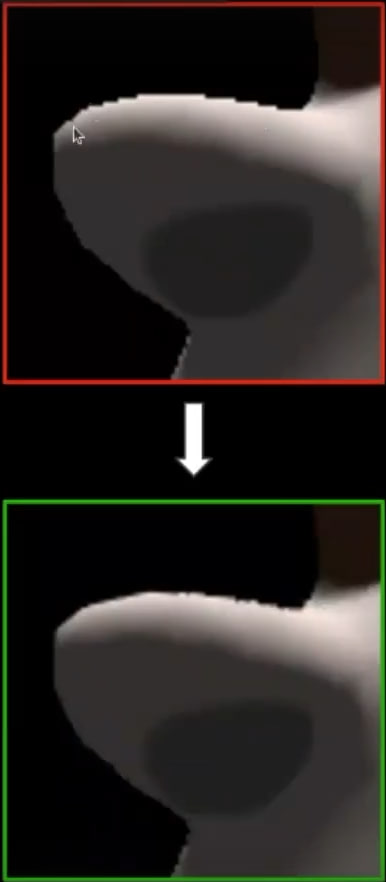

The anti-aliasing technique from graphics, which initially solved the problem of smoothing the boundaries of rasterized geometry, helps to solve the problem.

We do not know how to differentiate at the discontinuity points of functions. A correct differentiation method is needed that will spread the gradients through the discontinuity points. That is, it is necessary to parameterize the boundary function in the rendering procedure at the discontinuity points from the parameters by which we differentiate.

$\color{red}{Idea}$: introduce a dependence of the color of pixels when passing through a parameterized boundary continuous in the parameters of this boundary $→ \color{red}{interpolation\ along\ AB\ parameterized\ on\ face\ PQ}$

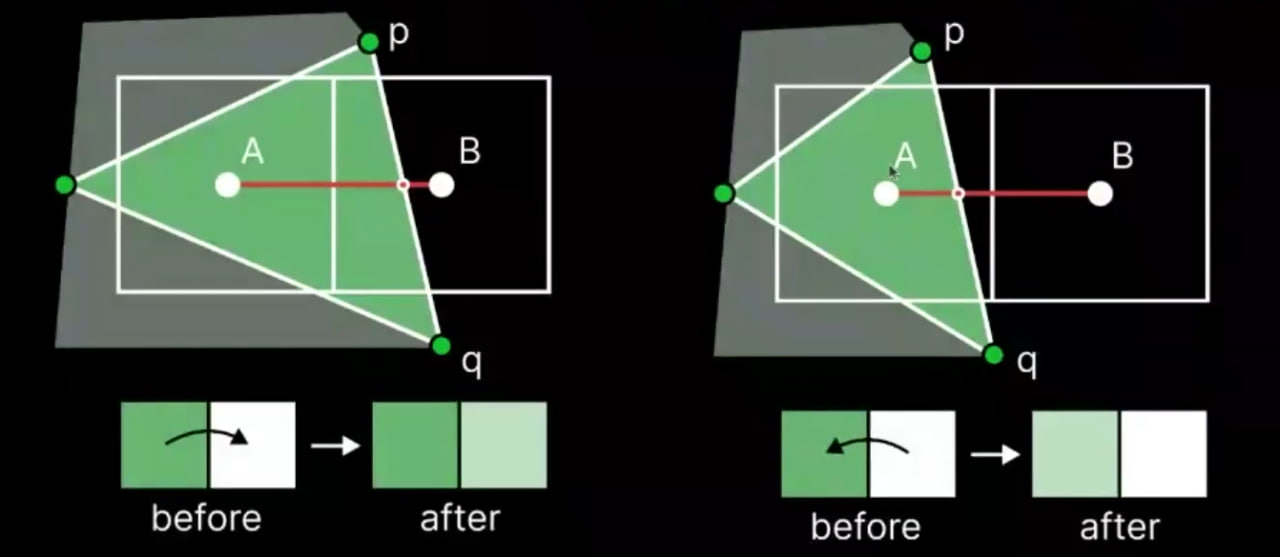

In [39]:
def transform_pos(mvp, pos):

    assert mvp.dim() == 3, "MVP must be 3D tensor"

    posw = homogenize_points(pos)

    return torch.einsum('nj,bij->bni', posw, mvp)

def render(texture, model, camera, light_dir, filter_mode='linear-mipmap-linear', resolution=(512, 512), max_mip_level=9):
    # project vertices
    mvp = camera.get_mvp()
    pos_clip = transform_pos(mvp, model.verts) # Translates vertices into clip space (MVP matrix).
    pos_clip = pos_clip.contiguous()

    # start rasterization
    glctx = dr.RasterizeCudaContext()
    rast_out, rast_out_db = dr.rasterize(glctx, pos_clip, model.faces, resolution=resolution) # Creates a mask with binary values ​​(no gradients yet).

    assert rast_out.shape[-1] == 4, "Raster output should have 4 channels"
    assert rast_out.shape[:2] == (pos_clip.shape[0], resolution[1]), "Raster size mismatch"

    texc, texd = dr.interpolate( # Associates pixels with texture coordinates.
        model.uvs[None, ...],
        rast_out,
        model.faces,
        rast_db=rast_out_db,
        diff_attrs='all'
    )

    assert torch.all(texc >= 0) and torch.all(texc <= 1), "UV coordinates out of [0,1] range"
    assert texc.shape[:-1] == rast_out.shape[:-1], "UV shape mismatch"

    projected_texture = dr.texture(
        texture[None, ...],
        texc,
        texd,
        filter_mode=filter_mode,
        max_mip_level=max_mip_level
    )
    projected_texture = dr.antialias(projected_texture, rast_out, pos_clip, model.faces) # Adds gradients

    assert projected_texture.shape[:-1] == texc.shape[:-1], "Texture sampling shape mismatch"
    assert torch.all(projected_texture >= 0) and torch.all(projected_texture <= 1), "Texture values out of range"

    mask = torch.clamp(rast_out[..., -1:], 0, 1)
    triangle_ids = (rast_out[..., 3].clamp(1.) - 1.).to(torch.long)

    assert torch.all(mask >= 0) and torch.all(mask <= 1), "Mask values out of range"
    assert triangle_ids.min() >= 0, "Negative triangle indices"
    assert triangle_ids.max() < len(model.normals), "Triangle index out of bounds"

    normals = model.normals[triangle_ids]

    diffuse_albedo = projected_texture[..., :3]
    light_dir = light_dir.view(-1, 1, 1, 3)
    diffuse_coefficient = (normals * light_dir).sum(-1, keepdim=True).clamp(0.) + 0.3
    output_color = (
        diffuse_coefficient * diffuse_albedo
    ).clamp(0., 1.)
    return torch.where(mask == 1, output_color, torch.tensor(0.9))

`projected_texture = dr.antialias(projected_texture, rast_out, pos_clip, model.faces)`

The `dr.antialias` function applies the method from the theory:


*   Finds breakpoints (triangle boundaries) via rast_out (rasterized data).
*   Blends the colors of neighboring pixels with a coefficient α calculated from the boundary parameterization.

In [40]:
def get_camera_parameters():
    camera_target = torch.tensor([0., 0., 0.])
    r = 2 * torch.tensor(1)
    return camera_target, r

camera_target, r = get_camera_parameters()

val_phis = torch.Tensor((
    [0.5 * math.pi * (0.5 + i) for i in range(4)]
    + [0.25 * math.pi * i for i in range(8)]
    + [0.25 * math.pi * i for i in range(8)]
))
val_thetas = torch.Tensor(4 * [0,] + 8 * [math.pi / 6] + 8 * [math.pi / 3])#.view(1, -1)

my_camera=Camera(batch_size=20, device='cuda:0', phi=val_phis, theta=val_thetas, camera_target=camera_target.to('cuda:0'), r=1)

**Stage 1. Breakpoints - how to find them?**

Breakpoints occur when different triangles that do not have common edges are rasterized into neighboring pixels (then visible artifacts appear - cracks or color jumps due to the abrupt transition between objects)

$p_1, p_2$ - centers of neighboring pixels

$i_1, i_2$ - indices of rasterized triangles (rasterize triangle = triangle covers the center of the pixel)

$\color{red}{Next\ only\ the\ closest\ in\ depth\ of\ these\ two\ is\ considered.}$

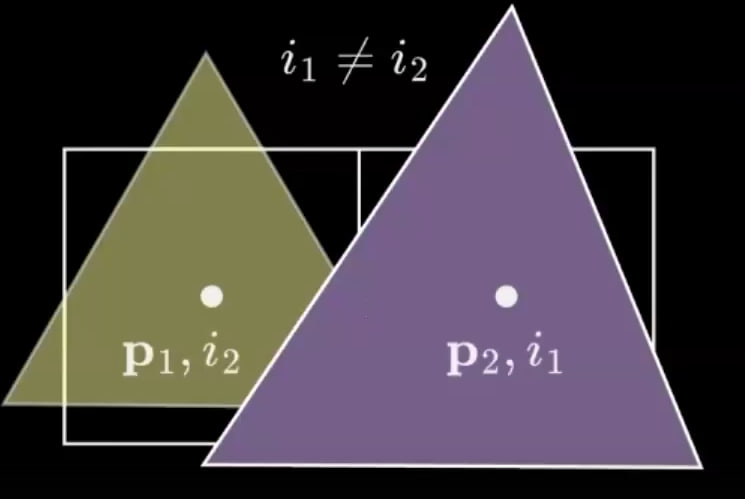

For the selected triangle, $\color{blue}{silhouette\ edges}$ are selected:

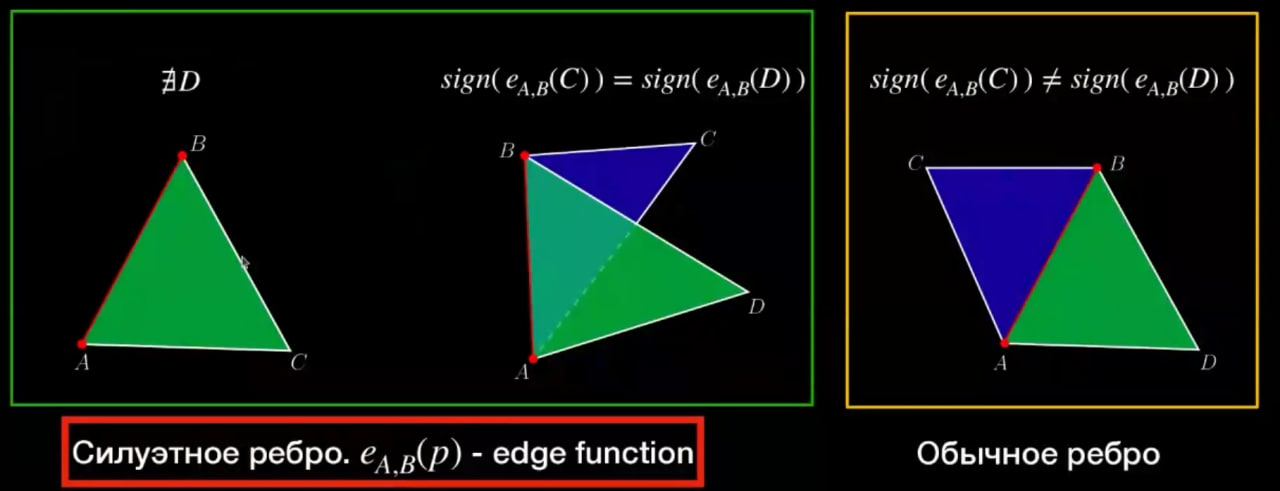

Simply put, a $\color{blue}{silhouette\ edge}$ is an edge of a triangle that is the boundary of an object in the current view.

**Step 2. Parameterization of the boundary**

The boundary is a straight line ($\color{orange}{orange}$): $$\langle (x_0, y_0), n \rangle = d$$

Normal: $$n = (y_0 - y_1, x_1 - x_0)$$

$d$ is the distance to the origin

$(x_o, y_0)$ is a point on the boundary

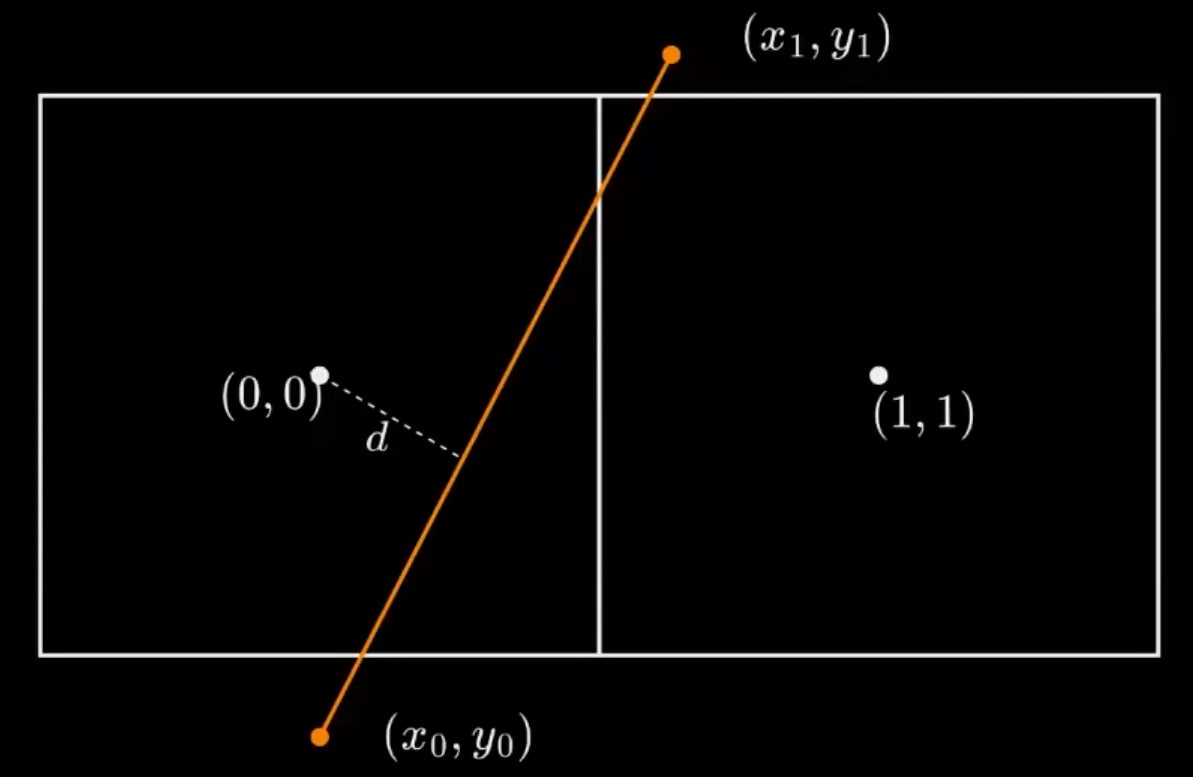

**Step 3. Color mixing coefficient**

The colors of the pixels are mixed linearly with the coefficient: $\color{red}{\alpha = 0.5 - c}$

This parameterization does not change the colors if the intersection point is the center of the segment and allows adding or subtracting colors when passing through this point.

The point $(c, 0)$ lies on the boundary: $$\langle (c, 0), n \rangle = d \implies \color{red}{\cases {c = x_0 - y_0 \frac {x_1 - x_0}{y_1 - y_0} \\ \alpha = 0.5 -c}}$$

The pixels are colored independently. In this picture:

* Left pixel ($c = 0.3$): $\alpha = 0.5 - 0.3 = 0.2 \implies$ take 20% of the color of the triangle of the neighboring pixel
* Right pixel ($c = 0.7$): $\alpha = 0.5 - 0.7 = -0.2 \implies$ take the color of the triangle on this pixel

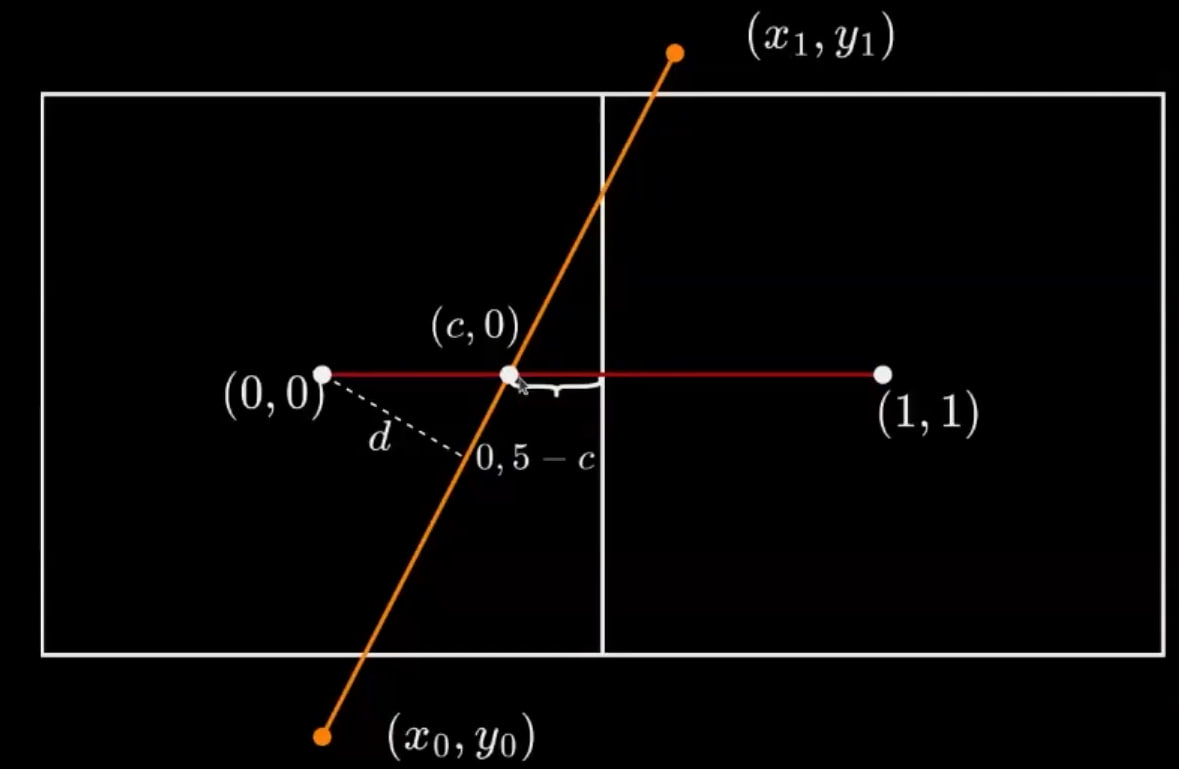

**Stage 4. Color mixing**

In the 1st case, the intersection point in pixel $B \implies$ we mix the color of pixel $A$ into pixel $B$

In the 2nd case, the intersection point in pixel $A \implies$ from pixel $B$ we mix the color into pixel $A$

$\color{green}{(In\ general,\ we\ mix\ colors\ into\ pixels\ from\ all\ neighboring\ pixels)}$

$\color{red}{After\ this\ we\ will\ be\ able\ to\ differentiate,\ since\ we\ have\ a\ smoother\ parameterization\ of\ the\ areas\ of\ the\ function\ discontinuity.}$

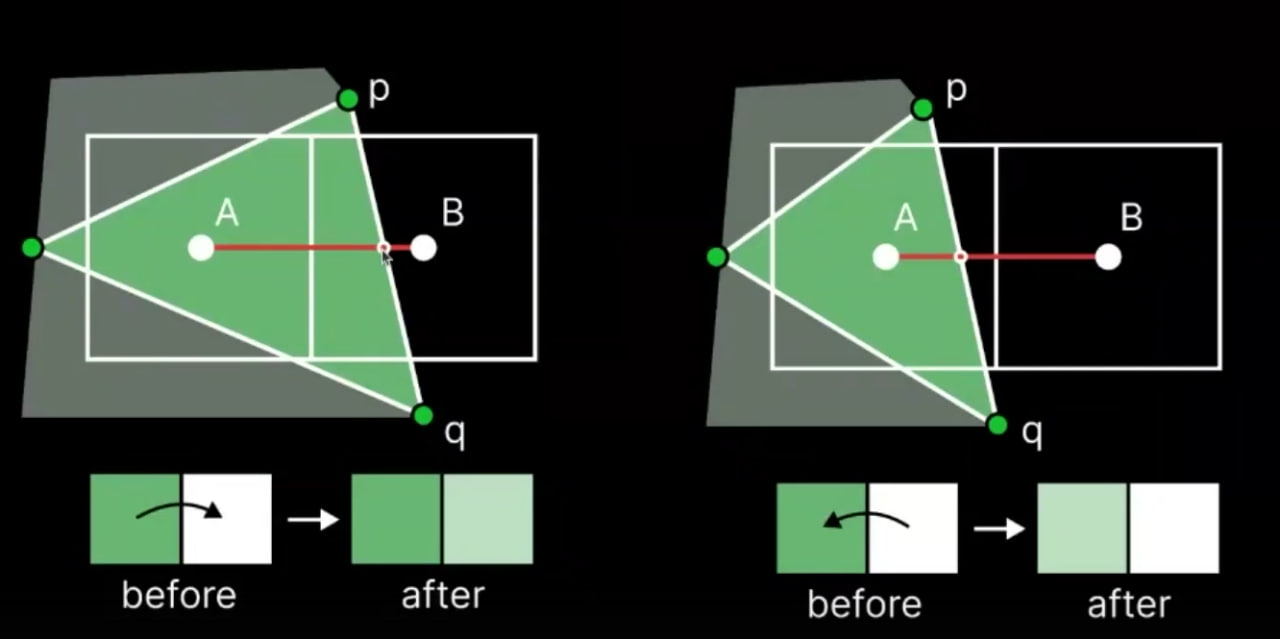

A clear example:

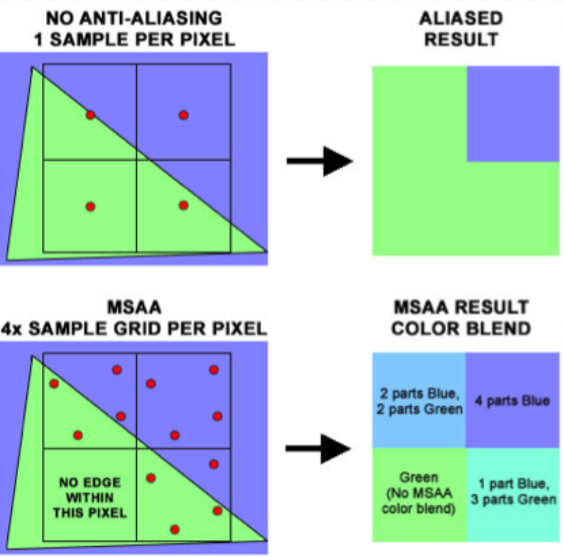

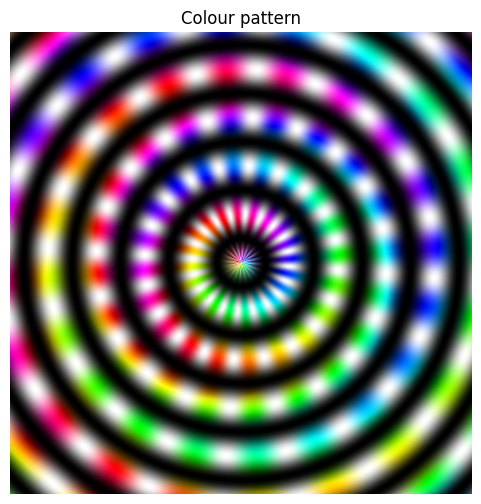

In [41]:
# hue_value = 0.4
# h = np.full((512, 512), hue_value)
# s = np.ones((512, 512))
# v = np.linspace(0, 1, 512).reshape(512, 1)
# hsv = np.dstack((h, s, np.tile(v, (1, 512))))
# rgb = hsv_to_rgb(hsv)

size = 512
y, x = np.ogrid[:size, :size]
x = (x - size / 2) / (size / 2)
y = (y - size / 2) / (size / 2)
radius = np.sqrt(x**2 + y**2)
angle = np.arctan2(y, x)
hue = np.mod((angle + np.pi) / (2 * np.pi) + 0.2 * np.sin(10 * radius), 1.0)
saturation = np.clip(0.5 + 0.5 * np.sin(20 * angle), 0, 1)
value = np.clip(0.5 + 0.5 * np.cos(30 * radius), 0, 1)

hsv = np.dstack((hue, saturation, value))

rgb = hsv_to_rgb(hsv)

plt.figure(figsize=(6, 6))
plt.imshow(rgb, origin='lower')
plt.axis('off')
plt.title('Colour pattern')
plt.show()

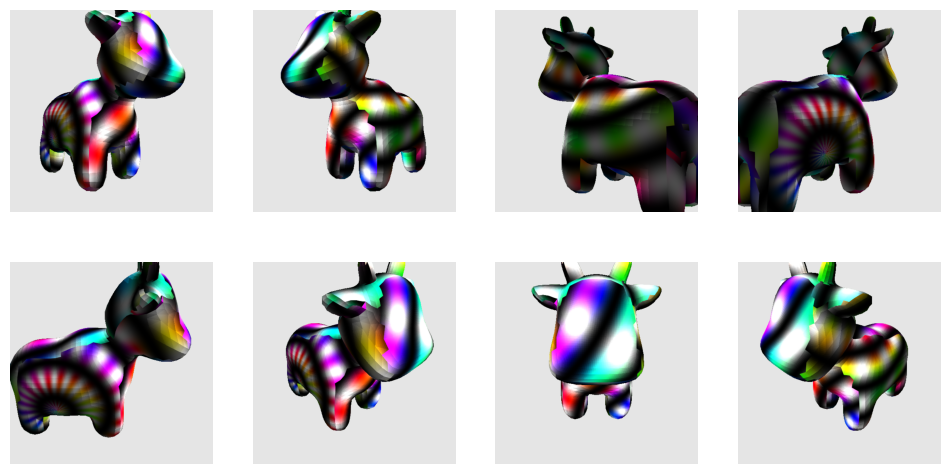

In [42]:
reference_texture = torch.nn.Parameter(torch.from_numpy(rgb).float().cuda())

reference_images = render(reference_texture, my_mesh, my_camera, light_dir, filter_mode='nearest').detach()
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(reference_images[i].clamp(0., 1.).detach().cpu())
    ax.axis('off')

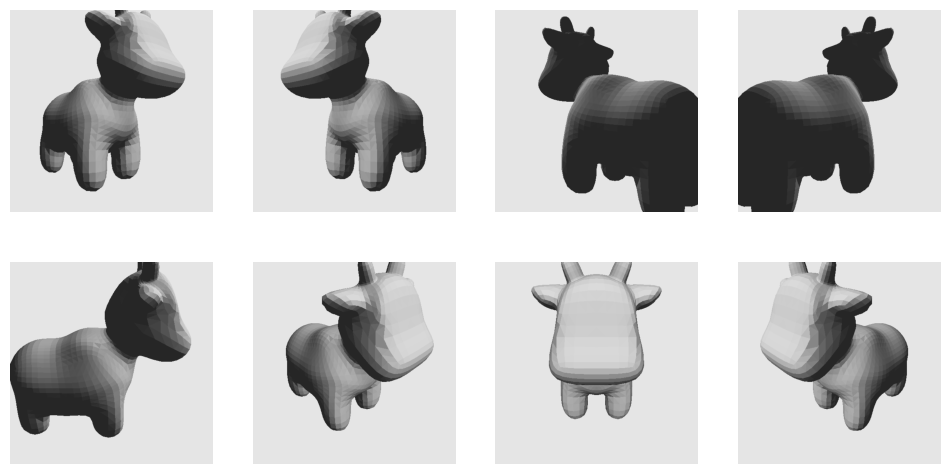

In [43]:
trained_texture = torch.nn.Parameter(0.5 + torch.zeros(512, 512, 3, device=torch.device('cuda:0')))

temp_images = render(trained_texture, my_mesh, my_camera, light_dir, filter_mode='nearest')

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(temp_images[i].clamp(0., 1.).detach().cpu())
    ax.axis('off')

In [44]:
predicted_images = render(trained_texture, my_mesh, my_camera, light_dir, filter_mode='nearest')
predicted_images.requires_grad

True

In [45]:
optimizer = torch.optim.Adam([trained_texture], lr=0.001)
t = trange(1024, desc='Bar desc', leave=True)

for i in t:
    predicted_images = render(trained_texture, my_mesh, my_camera, light_dir, filter_mode='nearest')
    # loss = ((reference_images - predicted_images) ** 2).mean(0).sum()
    loss = ((reference_images - predicted_images) ** 2).mean()
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    trained_texture.data = trained_texture.data.clamp(0., 1.)

    t.set_description(f"Step #{i}, Loss: {loss.detach().cpu():.5f}")
    t.refresh()

Step #1023, Loss: 0.00002: 100%|██████████| 1024/1024 [00:29<00:00, 34.25it/s]


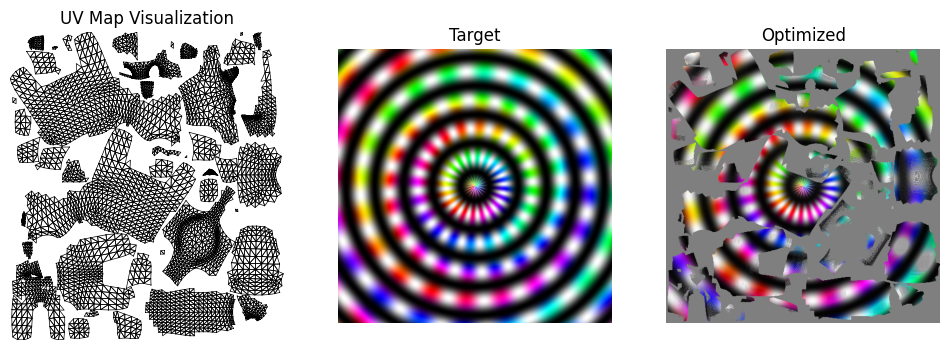

In [46]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

uvs = my_mesh.uvs.detach().cpu().numpy()
faces = my_mesh.faces.detach().cpu().numpy().astype(np.int64)
for face in faces:
    # face – [i0, i1, i2]; uvs[face].shape = (3,2)
    uv_tri = uvs[face]
    outline = np.vstack([uv_tri, uv_tri[0]])
    axs[0].plot(outline[:, 0], outline[:, 1], color='black', linewidth=0.5)

axs[0].set_xlim(0.0, 1.0)
axs[0].set_ylim(0.0, 1.0)
axs[0].axis('off')
axs[0].invert_yaxis()
axs[0].set_title('UV Map Visualization')

axs[1].imshow(reference_texture.detach().cpu())
axs[1].axis('off')
axs[1].set_title('Target')

axs[2].imshow(trained_texture.detach().cpu())
axs[2].axis('off')
axs[2].set_title('Optimized')

plt.show()

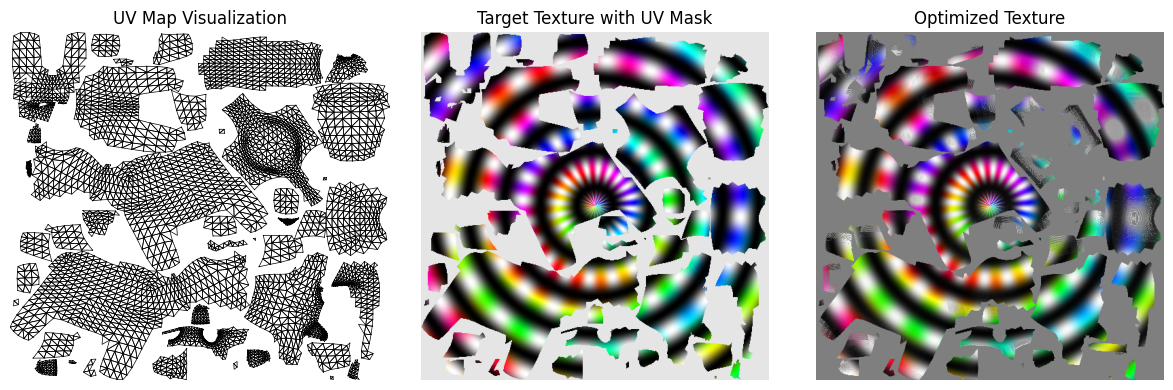

In [47]:
from matplotlib.path import Path
import matplotlib.patches as patches
from matplotlib import colors

def create_uv_mask(uvs, faces, resolution=512):
    mask = np.zeros((resolution, resolution), dtype=bool)

    x = np.linspace(0, 1, resolution)
    y = np.linspace(0, 1, resolution)
    X, Y = np.meshgrid(x, y, indexing='xy')
    points = np.vstack([X.ravel(), Y.ravel()]).T

    for face in faces:
        uv_tri = uvs[face]
        path = Path(uv_tri)
        mask_tri = path.contains_points(points).reshape(resolution, resolution)
        mask = mask | mask_tri

    return mask

uv_mask = create_uv_mask(uvs, faces, resolution=512)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

for face in faces:
    uv_tri = uvs[face]
    outline = np.vstack([uv_tri, uv_tri[0]])
    axs[0].plot(outline[:, 0], outline[:, 1], color='black', linewidth=0.5)
axs[0].set_xlim(0.0, 1.0)
axs[0].set_ylim(0.0, 1.0)
axs[0].axis('off')
axs[0].set_title('UV Map Visualization')

target_img = reference_texture.detach().cpu().numpy()
target_img_with_mask = np.full_like(target_img, 0.9)
target_img_with_mask[uv_mask] = target_img[uv_mask]
axs[1].imshow(target_img_with_mask, origin='lower')
axs[1].axis('off')
axs[1].set_title('Target Texture with UV Mask')

optimized_img = trained_texture.detach().cpu().numpy()
axs[2].imshow(optimized_img, origin='lower')
axs[2].axis('off')
axs[2].set_title('Optimized Texture')

plt.tight_layout()
plt.show()


To consolidate:

**Problem** → Binary mask in rasterize gives zero gradients.

**Solution** → dr.antialias adds smooth transitions through parameterization of boundaries.

**Result** → Gradients from loss.backward() update the texture.

Key points:



*   Without dr.antialias, optimization does not work.
*   The UV mask helps to understand which parts of the texture affect the rendering.